In [1]:
# Thesis plotting fonts: enforce minimum size 15 across all elements
import matplotlib as mpl
import matplotlib.pyplot as plt
from contextlib import contextmanager

MIN_FONT = 15

_DEF_RC = {
    'font.size': MIN_FONT,
    'axes.titlesize': max(MIN_FONT, 16),
    'axes.labelsize': MIN_FONT,
    'xtick.labelsize': MIN_FONT,
    'ytick.labelsize': MIN_FONT,
    'legend.fontsize': MIN_FONT,
    'figure.titlesize': max(MIN_FONT, 16),
    'axes.titleweight': 'bold',
    'axes.labelweight': 'regular'
}

def set_thesis_fonts(base: int = MIN_FONT) -> None:
    """Set global rcParams so every new figure starts with >= base font sizes.
    Safe to call multiple times; only raises values below the threshold.
    """
    for k, v in _DEF_RC.items():
        if 'size' in k:
            mpl.rcParams[k] = max(v, base)
        else:
            mpl.rcParams[k] = v

# --- Active post-hoc enforcement ---
import matplotlib.text as _mtext
import matplotlib.figure as _mfig
import matplotlib.axes as _maxes

def _raise_if_small(obj, minsize: int):
    try:
        fs = obj.get_fontsize()
        if fs < minsize:
            obj.set_fontsize(minsize)
    except Exception:
        pass

def enforce_min_fontsize(minsize: int = MIN_FONT, fig=None) -> None:
    """Traverse a figure (or all current figures if fig is None) and raise any text object fontsize < minsize.
    This does NOT modify external library source files (e.g. GMetrics), only the rendered objects.
    """
    figs = [fig] if fig is not None else [plt.figure(n) for n in plt.get_fignums()]
    for f in figs:
        for txt in f.findobj(match=lambda o: isinstance(o, _mtext.Text)):
            _raise_if_small(txt, minsize)

# --- Monkey patch common methods (axes + figure) to clamp explicit fontsize kwargs below threshold ---
_PATCHED = False

def _patch_methods(minsize: int = MIN_FONT):
    global _PATCHED
    if _PATCHED:
        return
    def _coerce(kwargs):
        fs = kwargs.get('fontsize')
        if fs is not None and fs < minsize:
            kwargs['fontsize'] = minsize
        return kwargs
    def _wrap(cls, name):
        if not hasattr(cls, name):
            return
        orig = getattr(cls, name)
        def wrapped(self, *args, **kwargs):
            _coerce(kwargs)
            return orig(self, *args, **kwargs)
        setattr(cls, name, wrapped)
    for meth in ('set_title', 'set_xlabel', 'set_ylabel', 'legend', 'text'):
        _wrap(_maxes.Axes, meth)
    _wrap(_mfig.Figure, 'suptitle')
    _PATCHED = True

_patch_methods()

@contextmanager
def thesis_plot(minsize: int = MIN_FONT):
    """Context manager: within block create plots; on exit enforce min font size.
    Usage:
        with thesis_plot():
            fig, ax = plt.subplots(); ax.set_title('My title', fontsize=8)  # auto-upgraded to 15
    """
    yield
    enforce_min_fontsize(minsize)

# Initialize rcParams immediately
set_thesis_fonts(MIN_FONT)


In [2]:
import h5py, os, numpy as np, matplotlib.pyplot as plt, math, pandas as pd
from pathlib import Path

# =============================================
# Robust feature loader for centroid + RMS data
# =============================================

def read_eval_centroids(h5_path: str):
    """Load centroid (z̄, ā, r̄) and RMS datasets from eval_features HDF5.
    Returns a dict with numpy arrays; reads eagerly inside file context.
    Includes fallbacks and a helpful warning if some datasets are missing.
    """
    if not os.path.isfile(h5_path):
        raise FileNotFoundError(f"Features file not found: {h5_path}")
    with h5py.File(h5_path, 'r') as f:
        req = ['/per_event/centroid_true', '/per_event/centroid_gen']
        for ds in req:
            if ds not in f:
                raise KeyError(f"Missing dataset {ds} in {h5_path}")
        cen_true = f['/per_event/centroid_true'][...]
        cen_gen  = f['/per_event/centroid_gen'][...]

        # Try canonical names first
        paths = {
            'rms_long_true': '/per_event/rms_longitudinal_true',
            'rms_long_gen':  '/per_event/rms_longitudinal_gen',
            'rms_lat_true':  '/per_event/rms_lateral_true',
            'rms_lat_gen':   '/per_event/rms_lateral_gen',
            'rms_a_true':    '/per_event/rms_a_true',
            'rms_a_gen':     '/per_event/rms_a_gen',
            'rms_r_true':    '/per_event/rms_r_true',
            'rms_r_gen':     '/per_event/rms_r_gen',
        }

        out = dict(centroid_true=cen_true, centroid_gen=cen_gen)
        missing = []
        for key, p in paths.items():
            if p in f:
                out[key] = f[p][...]
            else:
                out[key] = None
                missing.append((key, p))

        # Fallback synonyms (older files) – conservative guesses
        # Only fill if still None and a close synonym exists
        synonyms = {
            'rms_long_true': ['/per_event/rms_z_true'],
            'rms_long_gen':  ['/per_event/rms_z_gen'],
            'rms_lat_true':  ['/per_event/rms_xy_true', '/per_event/rms_perp_true'],
            'rms_lat_gen':   ['/per_event/rms_xy_gen',  '/per_event/rms_perp_gen'],
            'rms_a_true':    ['/per_event/rms_angular_true', '/per_event/rms_angle_true'],
            'rms_a_gen':     ['/per_event/rms_angular_gen',  '/per_event/rms_angle_gen'],
        }
        for key, cands in synonyms.items():
            if out.get(key) is None:
                for cand in cands:
                    if cand in f:
                        out[key] = f[cand][...]
                        break

        # Attach attrs for reference
        out['attrs'] = {k: f.attrs[k] for k in f.attrs.keys()}

    # Helpful warning if important datasets are missing
    still_missing = [k for k in ['rms_a_true','rms_a_gen','rms_long_true','rms_long_gen','rms_lat_true','rms_lat_gen'] if out.get(k) is None]
    if still_missing:
        print('[read_eval_centroids] Warning: Missing datasets:', ', '.join(still_missing))
        print('  If this is an older features file, regenerate it with the updated make_eval_features.build_eval_features(overwrite=True).')

    return out

# =============================
# Single-component histogram with configurable scales
# =============================

def _density_hist(x, bins=60, rng=None):
    counts, edges = np.histogram(x, bins=bins, range=rng, density=True)
    return counts, edges


def plot_centroid_hist(features: dict, component: str='z', bins=60,
                        range_pad=0.03, figsize=(7.5,5.0),
                        truth_color='#4C72B0', model_color='#DD8452',
                        save_path=None, title=None,
                        x_scale: str = 'linear', y_scale: str = 'linear',
                        x_linthresh: float | None = None, y_linthresh: float | None = None):
    """Overlay truth vs model centroid distributions. component ∈ {'z','a','r'}.
    Supports linear or symlog axes with adjustable linthresh."""
    idx_map = {'z':0,'a':1,'r':2}
    if component not in idx_map:
        raise ValueError("component must be 'z','a', or 'r'")
    i = idx_map[component]
    ct = features['centroid_true'][:, i]
    cg = features['centroid_gen'][:, i]
    xmin = min(ct.min(), cg.min()); xmax = max(ct.max(), cg.max())
    dx = xmax - xmin; pad = range_pad * dx if dx > 0 else 1.0
    hist_range = (xmin - pad, xmax + pad)
    t_counts, edges = _density_hist(ct, bins=bins, rng=hist_range)
    g_counts, _     = _density_hist(cg, bins=bins, rng=hist_range)

    fig, ax = plt.subplots(figsize=figsize)
    ax.margins(x=0, y=0)
    stairs_x = np.repeat(edges, 2)[1:-1]; stairs_y_t = np.repeat(t_counts, 2)
    ax.fill_between(stairs_x, stairs_y_t, step='post', color=truth_color, alpha=0.35, label='Truth')
    ax.step(edges[:-1], t_counts, where='post', color=truth_color, linewidth=1.2)
    ax.step(edges[:-1], g_counts, where='post', color=model_color, linewidth=2.0, label='Model')

    label_map = {'z':'Longitudinal z̄ (mm)', 'a':'Angular ā (rad)', 'r':'Radial r̄ (mm)'}
    ax.set_xlabel(label_map[component], fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.grid(alpha=0.3)
    if title is None: title = f"Centroid {component}-component distribution"
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, fontsize=12, loc='best')

    if x_scale == 'symlog':
        ax.set_xscale('symlog', linthresh=x_linthresh if x_linthresh else max(1e-12, (xmax - xmin)*0.01))
    elif x_scale != 'linear':
        raise ValueError(f"Unknown x_scale {x_scale}")
    if y_scale == 'symlog':
        pos_vals = np.concatenate([t_counts[t_counts>0], g_counts[g_counts>0]])
        default_y_lt = pos_vals.min() if pos_vals.size else 1e-12
        ax.set_yscale('symlog', linthresh=y_linthresh if y_linthresh else default_y_lt)
    elif y_scale != 'linear':
        raise ValueError(f"Unknown y_scale {y_scale}")

    plt.tight_layout()
    if save_path:
        Path(os.path.dirname(save_path) or '.').mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path)
    plt.show()
    return {'n_bins': int(bins), 'x_scale': x_scale, 'y_scale': y_scale}

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ===============================================================
# 1D → 2D FLOW TO 3 MODES (exact inverse, visible clusters)
# We start from a univariate Gaussian u ~ N(0,1) and add an auxiliary
# independent v ~ N(0,1) to form z = [u, v] in R^2. Then we apply two
# triangular (coupling) layers with smooth gating to push mass towards
# three target centers. The map is bijective with closed-form inverse.
# ===============================================================

def softmax(x, axis=-1):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

# Smooth 1D radial basis soft assignments along a coordinate
def rbf_gates(coord, mus, tau=0.9, beta=1.0):
    # coord: (N,), mus: (K,)
    diffs = coord[:, None] - mus[None, :]
    logits = -0.5 * (diffs / tau)**2 * beta
    return softmax(logits, axis=1)  # (N, K)

# Coupling Layer A (condition on x):
#   y1 = x
#   y2 = x2 * exp(s(x1)) + t(x1)
def coupling_x_forward(z, mus_x, t_y, s_y, tau=0.9, beta=1.0):
    x1, x2 = z[:, 0], z[:, 1]
    gates = rbf_gates(x1, mus_x, tau=tau, beta=beta)       # (N, K)
    t = gates @ t_y                                         # (N,) translation in y
    s = gates @ s_y                                         # (N,) log-scale in y
    y1 = x1
    y2 = x2 * np.exp(s) + t
    return np.column_stack([y1, y2])

def coupling_x_inverse(y, mus_x, t_y, s_y, tau=0.9, beta=1.0):
    y1, y2 = y[:, 0], y[:, 1]
    gates = rbf_gates(y1, mus_x, tau=tau, beta=beta)
    t = gates @ t_y
    s = gates @ s_y
    x1 = y1
    x2 = (y2 - t) * np.exp(-s)
    return np.column_stack([x1, x2])

# Coupling Layer B (condition on y):
#   z2 = y2
#   z1 = y1 * exp(ŝ(y2)) + t'(y2)
def coupling_y_forward(y, mus_y, t_x, s_x, tau=0.9, beta=1.0):
    y1, y2 = y[:, 0], y[:, 1]
    gates = rbf_gates(y2, mus_y, tau=tau, beta=beta)       # (N, K)
    t = gates @ t_x                                         # (N,) translation in x
    s = gates @ s_x                                         # (N,) log-scale in x
    z2 = y2
    z1 = y1 * np.exp(s) + t
    return np.column_stack([z1, z2])

def coupling_y_inverse(z, mus_y, t_x, s_x, tau=0.9, beta=1.0):
    z1, z2 = z[:, 0], z[:, 1]
    gates = rbf_gates(z2, mus_y, tau=tau, beta=beta)
    t = gates @ t_x
    s = gates @ s_x
    y2 = z2
    y1 = (z1 - t) * np.exp(-s)
    return np.column_stack([y1, y2])

# Compose the two layers

def tri_modal_forward(z, cfg):
    y = coupling_x_forward(z, cfg['mus_x'], cfg['t_y'], cfg['s_y'], cfg['tau'], cfg['beta'])
    out = coupling_y_forward(y, cfg['mus_y'], cfg['t_x'], cfg['s_x'], cfg['tau'], cfg['beta'])
    return out

def tri_modal_inverse(y, cfg):
    z1 = coupling_y_inverse(y, cfg['mus_y'], cfg['t_x'], cfg['s_x'], cfg['tau'], cfg['beta'])
    out = coupling_x_inverse(z1, cfg['mus_x'], cfg['t_y'], cfg['s_y'], cfg['tau'], cfg['beta'])
    return out

# Parameters to create three clear clusters near target centers
K = 3
centers = np.array([[ 2.2,  0.0],   # c1
                     [-1.4,  1.9],  # c2
                     [-1.4, -1.9]]) # c3

# Gate locations along x and y
mus_x = np.array([-2.0, 0.0, 2.0])
mus_y = np.array([-2.0, 0.0, 2.0])
# Translations chosen to pull mass towards centers (two alternating layers)
t_y = centers[:, 1]   # shift y based on x gate
t_x = centers[:, 0]   # shift x based on y gate
# Mild negative scales to concentrate around centers without folding
s_y = np.array([-0.35, -0.25, -0.35])  # log-scales on y
s_x = np.array([-0.35, -0.25, -0.35])  # log-scales on x

cfg = dict(mus_x=mus_x, mus_y=mus_y, t_y=t_y, t_x=t_x, s_y=s_y, s_x=s_x, tau=0.9, beta=1.2)

print("="*72)
print("1D → 2D FLOW: Gaussian to tri-modal 2D (exact inverse, curved grid)")
print("="*72)

# 1) Base sampling: start from 1D Gaussian u, add aux noise v
n = 4000
u = np.random.normal(0, 1, size=n)
v = np.random.normal(0, 1, size=n)
z = np.column_stack([u, v])

# 2) Forward map
y = tri_modal_forward(z, cfg)

# 3) Inverse map (exact)
z_rec = tri_modal_inverse(y, cfg)
rec_err = np.mean(np.abs(z - z_rec))
print(f"Reconstruction mean abs error: {rec_err:.6e}")

'''
# 4) Visualization
fig = plt.figure(figsize=(18, 10))

# Panel 1: 1D base u and 2D base scatter
ax1 = plt.subplot(2, 3, 1)
ax1.hist(u, bins=60, density=True, color='tab:blue', alpha=0.6, label='u ~ N(0,1)')
ax1.set_title('Base 1D Gaussian (u)')
ax1.legend()

ax2 = plt.subplot(2, 3, 2)
ax2.scatter(z[:,0], z[:,1], s=6, alpha=0.25, c='tab:blue', edgecolors='none')
ax2.set_title('Base 2D (u, v) with straight grid')
for t in np.linspace(-3,3,9):
    ax2.plot([-3,3],[t,t],'#8da0cb',alpha=0.5,lw=1)
    ax2.plot([t,t],[-3,3],'#fc8d62',alpha=0.5,lw=1)
ax2.set_xlim(-4,4); ax2.set_ylim(-4,4); ax2.set_aspect('equal')

# Panel 2: Transformed y with curved grid
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(y[:,0], y[:,1], s=6, alpha=0.25, c='tab:orange', edgecolors='none')
# Draw curved grid by transforming straight lines
grid_vals = np.linspace(-3,3,9)
line = np.linspace(-3,3,160)
for t in grid_vals:
    zl = np.column_stack([line, np.full_like(line, t)])
    yl = tri_modal_forward(zl, cfg)
    ax3.plot(yl[:,0], yl[:,1], '#8da0cb', alpha=0.7, lw=1.6)
for t in grid_vals:
    zl = np.column_stack([np.full_like(line, t), line])
    yl = tri_modal_forward(zl, cfg)
    ax3.plot(yl[:,0], yl[:,1], '#fc8d62', alpha=0.7, lw=1.6)
ax3.set_title('Transformed y (three visible modes)')
ax3.set_xlim(-4.5,4.5); ax3.set_ylim(-4.5,4.5); ax3.set_aspect('equal')

# Panel 3: Pure curved grid
ax4 = plt.subplot(2, 3, 4)
for t in grid_vals:
    zl = np.column_stack([line, np.full_like(line, t)])
    yl = tri_modal_forward(zl, cfg)
    ax4.plot(yl[:,0], yl[:,1], '#8da0cb', alpha=0.9, lw=2)
for t in grid_vals:
    zl = np.column_stack([np.full_like(line, t), line])
    yl = tri_modal_forward(zl, cfg)
    ax4.plot(yl[:,0], yl[:,1], '#fc8d62', alpha=0.9, lw=2)
ax4.set_title('Curved grid (space warping)')
ax4.set_xlim(-4.5,4.5); ax4.set_ylim(-4.5,4.5); ax4.set_aspect('equal')

# Panel 4: Reconstructed z
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(z_rec[:,0], z_rec[:,1], s=6, alpha=0.25, c='tab:green', edgecolors='none')
for t in np.linspace(-3,3,9):
    ax5.plot([-3,3],[t,t],'#8da0cb',alpha=0.4,lw=1)
    ax5.plot([t,t],[-3,3],'#fc8d62',alpha=0.4,lw=1)
ax5.set_title(f'Reconstruction (mean |Δ| = {rec_err:.3e})')
ax5.set_xlim(-4,4); ax5.set_ylim(-4,4); ax5.set_aspect('equal')

# Panel 5: Cluster centers overlay
ax6 = plt.subplot(2, 3, 6)
ax6.scatter(y[:,0], y[:,1], s=5, alpha=0.12, c='tab:gray', edgecolors='none')
ax6.scatter(centers[:,0], centers[:,1], c=['#1b9e77','#d95f02','#7570b3'], s=120, marker='X', label='targets')
ax6.set_title('Target centers (markers)'); ax6.legend(loc='lower right')
ax6.set_xlim(-4.5,4.5); ax6.set_ylim(-4.5,4.5); ax6.set_aspect('equal')

plt.tight_layout(); plt.show()
'''

1D → 2D FLOW: Gaussian to tri-modal 2D (exact inverse, curved grid)
Reconstruction mean abs error: 1.671152e-16


"\n# 4) Visualization\nfig = plt.figure(figsize=(18, 10))\n\n# Panel 1: 1D base u and 2D base scatter\nax1 = plt.subplot(2, 3, 1)\nax1.hist(u, bins=60, density=True, color='tab:blue', alpha=0.6, label='u ~ N(0,1)')\nax1.set_title('Base 1D Gaussian (u)')\nax1.legend()\n\nax2 = plt.subplot(2, 3, 2)\nax2.scatter(z[:,0], z[:,1], s=6, alpha=0.25, c='tab:blue', edgecolors='none')\nax2.set_title('Base 2D (u, v) with straight grid')\nfor t in np.linspace(-3,3,9):\n    ax2.plot([-3,3],[t,t],'#8da0cb',alpha=0.5,lw=1)\n    ax2.plot([t,t],[-3,3],'#fc8d62',alpha=0.5,lw=1)\nax2.set_xlim(-4,4); ax2.set_ylim(-4,4); ax2.set_aspect('equal')\n\n# Panel 2: Transformed y with curved grid\nax3 = plt.subplot(2, 3, 3)\nax3.scatter(y[:,0], y[:,1], s=6, alpha=0.25, c='tab:orange', edgecolors='none')\n# Draw curved grid by transforming straight lines\ngrid_vals = np.linspace(-3,3,9)\nline = np.linspace(-3,3,160)\nfor t in grid_vals:\n    zl = np.column_stack([line, np.full_like(line, t)])\n    yl = tri_modal_for

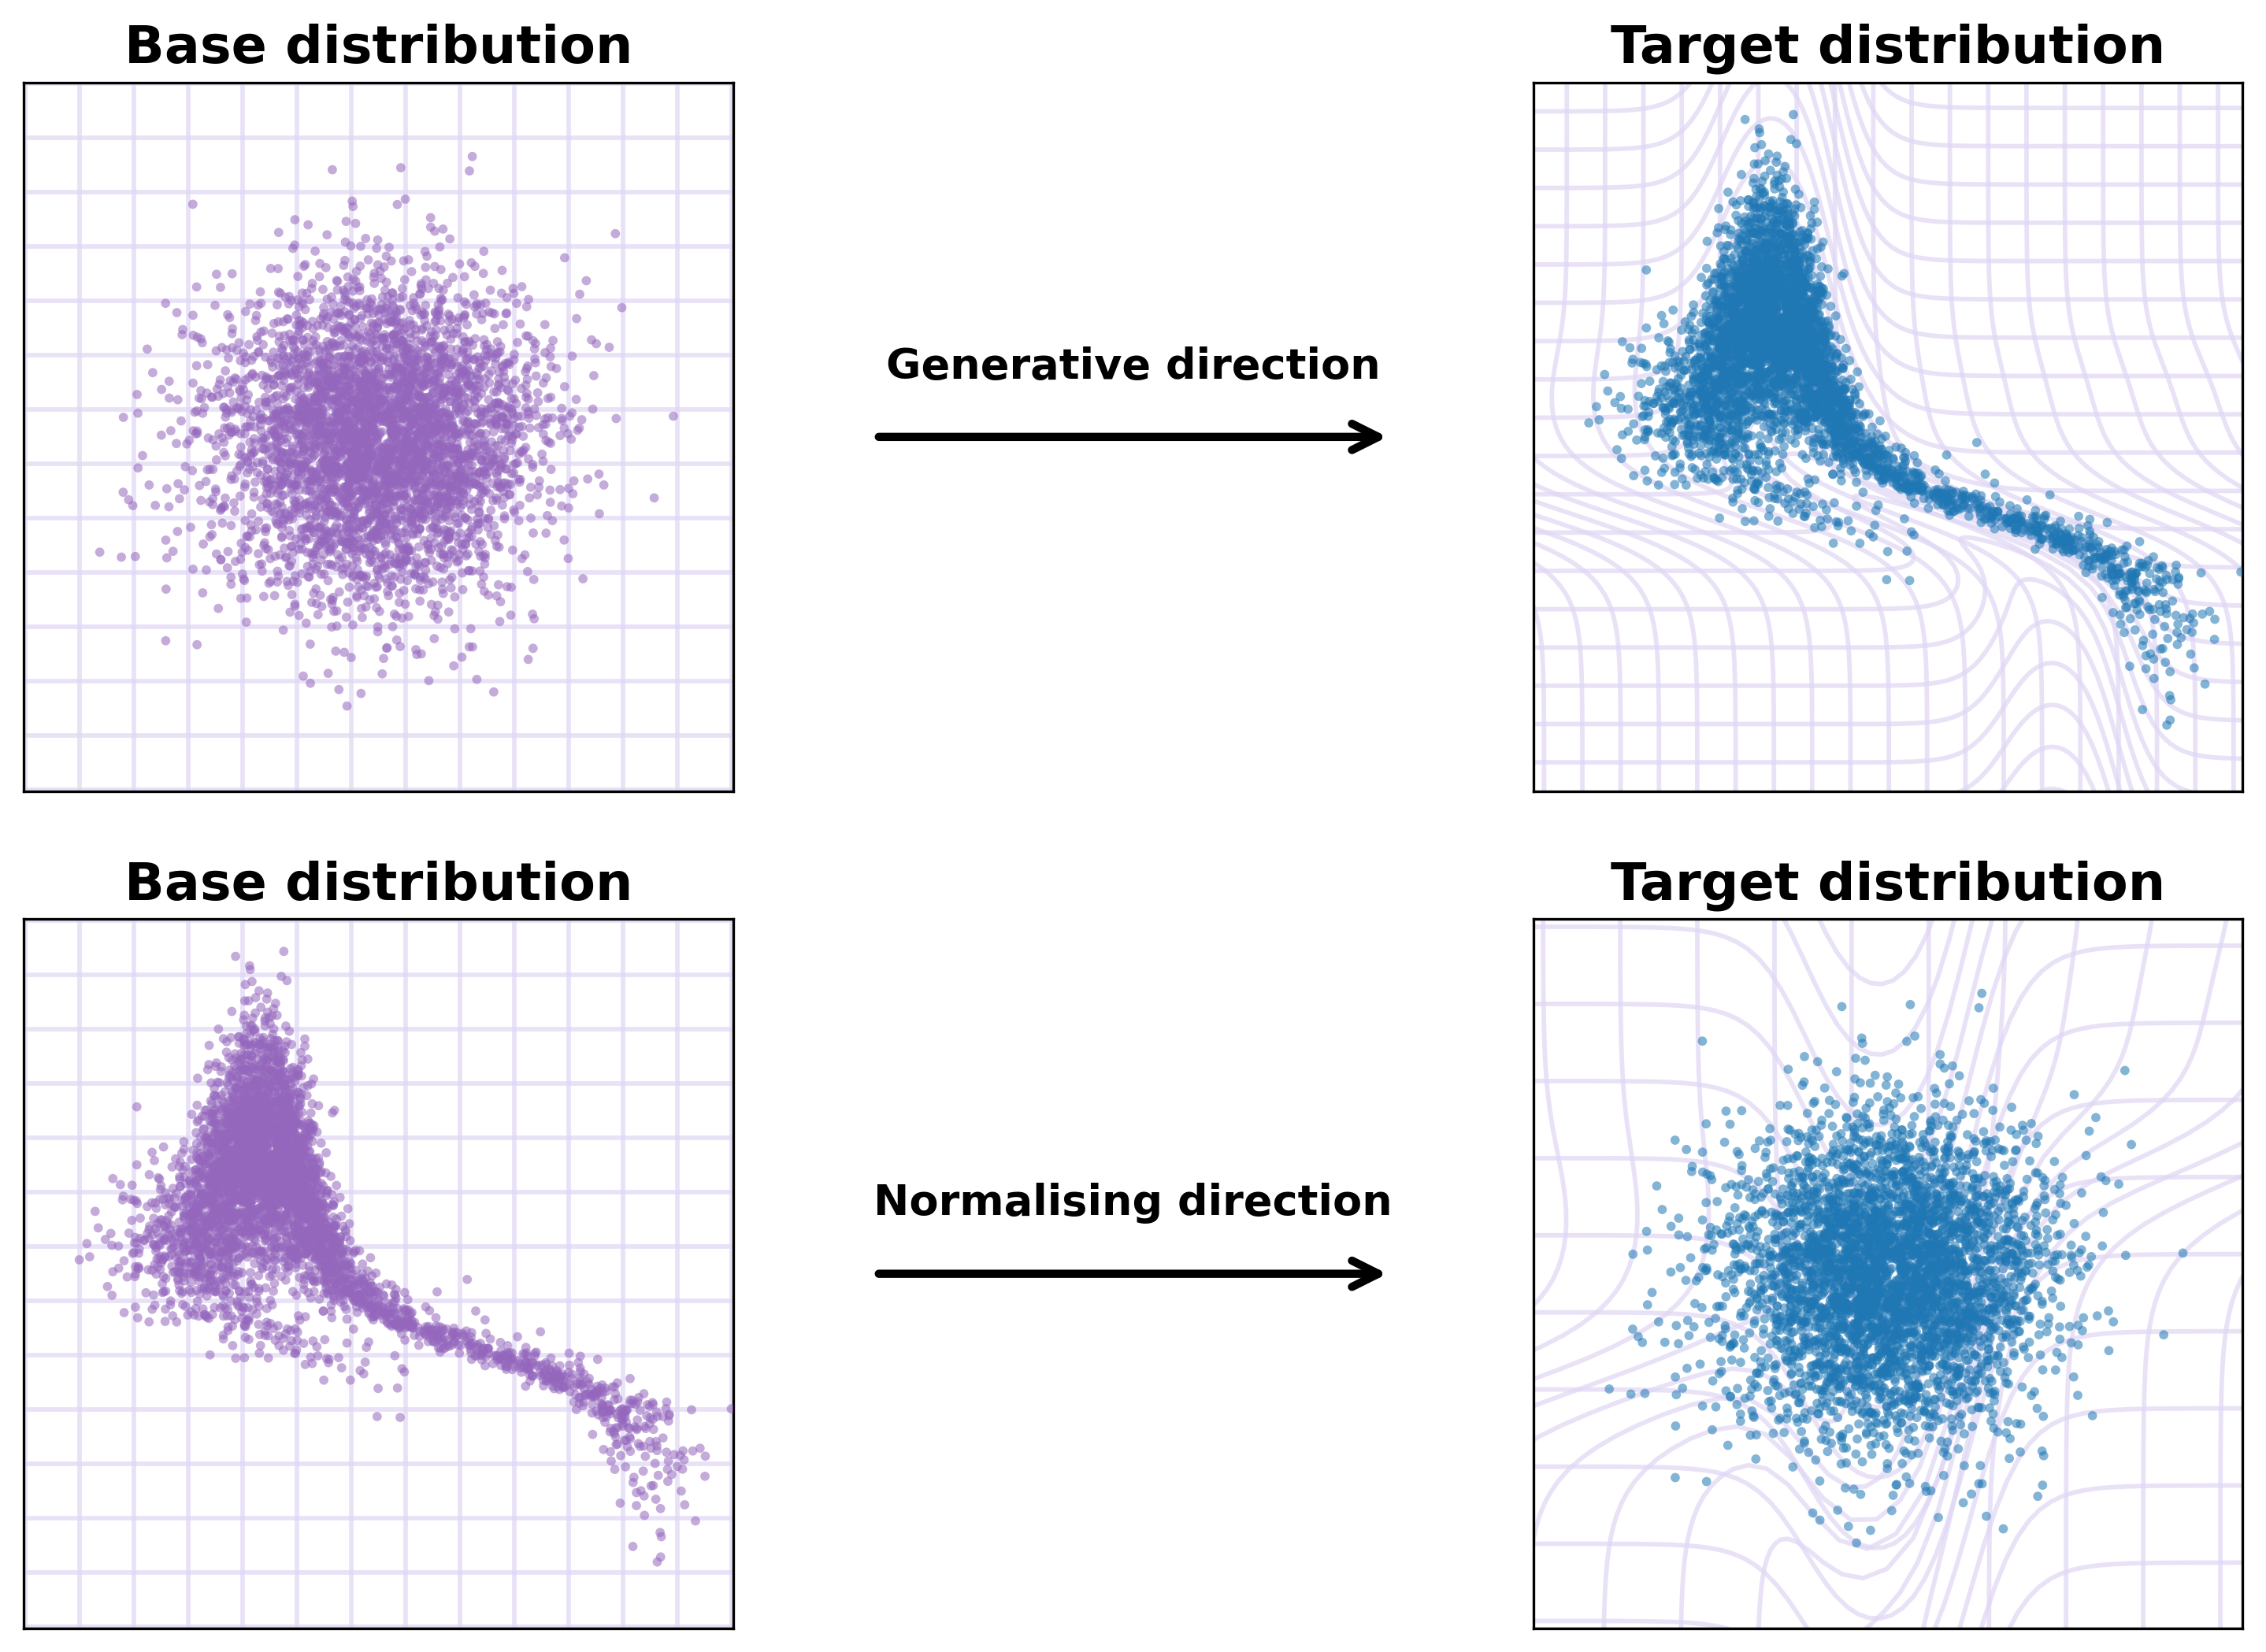

In [4]:
# 4-panel: generative vs normalizing directions with filled-canvas grids
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Require the tri-modal flow defined earlier
assert 'tri_modal_forward' in globals() and 'tri_modal_inverse' in globals() and 'cfg' in globals(), \
    "Run the tri-modal flow cell first to define tri_modal_forward/inverse and cfg."

# Sample fresh base Gaussian and transform
np.random.seed(7)
n = 4000
z = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], n)
y = tri_modal_forward(z, cfg)

# Grid parameters: lines fill the canvas (±30) but we zoom to ±4.5 in view
num_lines = 30
line_extent = 30.0
points_per_line = 600
vals = np.linspace(-10, 10, num_lines)
line = np.linspace(-line_extent, line_extent, points_per_line)

# Helpers to draw grids

def draw_straight_grid(ax, color_h="#8da0cb", color_v="#fc8d62", alpha=0.8, lw=1.4):
    for t in vals:
        ax.plot([-line_extent, line_extent], [t, t], color_h, alpha=alpha, lw=lw, zorder=1)
    for t in vals:
        ax.plot([t, t], [-line_extent, line_extent], color_v, alpha=alpha, lw=lw, zorder=1)

def draw_warped_grid_forward(ax, color_h="#8da0cb", color_v="#fc8d62", alpha=0.9, lw=1.4):
    # Warp straight lines from z-space into y-space using the forward map
    for t in vals:
        zl = np.column_stack([line, np.full_like(line, t)])
        yl = tri_modal_forward(zl, cfg)
        ax.plot(yl[:, 0], yl[:, 1], color_h, alpha=alpha, lw=lw, zorder=1)
    for t in vals:
        zl = np.column_stack([np.full_like(line, t), line])
        yl = tri_modal_forward(zl, cfg)
        ax.plot(yl[:, 0], yl[:, 1], color_v, alpha=alpha, lw=lw, zorder=1)

def draw_warped_grid_inverse(ax, color_h="#8da0cb", color_v="#fc8d62", alpha=0.9, lw=1.4):
    # Warp straight lines from y-space back into z-space using the inverse map
    for t in vals:
        yl = np.column_stack([line, np.full_like(line, t)])
        zl = tri_modal_inverse(yl, cfg)
        ax.plot(zl[:, 0], zl[:, 1], color_h, alpha=alpha, lw=lw, zorder=1)
    for t in vals:
        yl = np.column_stack([np.full_like(line, t), line])
        zl = tri_modal_inverse(yl, cfg)
        ax.plot(zl[:, 0], zl[:, 1], color_v, alpha=alpha, lw=lw, zorder=1)

# Make the 2x2 figure with more horizontal space
fig = plt.figure(figsize=(15, 8.5), dpi = 300)

# Create GridSpec for custom spacing between columns
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.22, hspace=0.18)

alpha_scatter = 0.55
alpha_grid = 0.7
view_lim = 4.5

# Top-left: Base Gaussian (z) with straight grid
ax_tl = fig.add_subplot(gs[0, 0])
draw_straight_grid(ax_tl, alpha=alpha_grid, color_h='#e0d7f5', color_v='#e0d7f5')
ax_tl.scatter(z[:, 0], z[:, 1], s=8, alpha=alpha_scatter, c='#9467bd', edgecolors='none', zorder=3)
ax_tl.set_title('Base distribution')
ax_tl.set_xlim(-view_lim, view_lim); ax_tl.set_ylim(-view_lim, view_lim); ax_tl.set_aspect('equal'); ax_tl.grid(False)

# Top-right: Transformed distribution y with warped grid UNDER the scatter
ax_tr = fig.add_subplot(gs[0, 1])
draw_warped_grid_forward(ax_tr, alpha = alpha_grid, color_h='#e0d7f5', color_v='#e0d7f5')
ax_tr.scatter(y[:, 0], y[:, 1], s=8, alpha=alpha_scatter, c='#1f77b4', edgecolors='none', zorder=3)
ax_tr.set_title('Target distribution')
ax_tr.set_xlim(-view_lim, view_lim); ax_tr.set_ylim(-view_lim, view_lim); ax_tr.set_aspect('equal'); ax_tr.grid(False)

# Bottom-left: Same y but with straight (axis-aligned) grid
ax_bl = fig.add_subplot(gs[1, 0])
draw_straight_grid(ax_bl, alpha = alpha_grid, color_h='#e0d7f5', color_v='#e0d7f5')
ax_bl.scatter(y[:, 0], y[:, 1], s=8, alpha=alpha_scatter, c='#9467bd', edgecolors='none', zorder=3)
ax_bl.set_title('Base distribution')
ax_bl.set_xlim(-view_lim, view_lim); ax_bl.set_ylim(-view_lim, view_lim); ax_bl.set_aspect('equal'); ax_bl.grid(False)

# Bottom-right: Base Gaussian z with INVERSE-warped grid (y → z)
ax_br = fig.add_subplot(gs[1, 1])
draw_warped_grid_inverse(ax_br, alpha = alpha_grid, color_h='#e0d7f5', color_v='#e0d7f5')
ax_br.scatter(z[:, 0], z[:, 1], s=8, alpha=alpha_scatter, c='#1f77b4', edgecolors='none', zorder=3)
ax_br.set_title('Target distribution')
ax_br.set_xlim(-view_lim, view_lim); ax_br.set_ylim(-view_lim, view_lim); ax_br.set_aspect('equal'); ax_br.grid(False)

# Remove axis ticks and labels for a cleaner look
for ax in (ax_tl, ax_tr, ax_bl, ax_br):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Determine the y=0 position in each row (in axes fractions)
y0_top_axes = ax_tl.transAxes.inverted().transform(ax_tl.transData.transform((0, 0)))[1]
y0_bot_axes = ax_bl.transAxes.inverted().transform(ax_bl.transData.transform((0, 0)))[1]

# Convert axis-edge points to figure coordinates
start_top_fig = np.array(fig.transFigure.inverted().transform(ax_tl.transAxes.transform((1.0, y0_top_axes))))
end_top_fig = np.array(fig.transFigure.inverted().transform(ax_tr.transAxes.transform((0.0, y0_top_axes))))
start_bot_fig = np.array(fig.transFigure.inverted().transform(ax_bl.transAxes.transform((1.0, y0_bot_axes))))
end_bot_fig = np.array(fig.transFigure.inverted().transform(ax_br.transAxes.transform((0.0, y0_bot_axes))))

# Apply horizontal padding so arrows stay clear of subplot edges
pad = 0.02
start_top_fig[0] += pad
end_top_fig[0] -= pad
start_bot_fig[0] += pad
end_bot_fig[0] -= pad

def center_set_length(p0, p1, target_length):
    """Set segment length (figure coords) while keeping it centered."""
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    direction = p1 - p0
    norm = np.linalg.norm(direction)
    if norm == 0:
        return p0, p1
    unit = direction / norm
    midpoint = 0.5 * (p0 + p1)
    half_vec = 0.5 * target_length * unit
    return midpoint - half_vec, midpoint + half_vec

# Use a fixed base length in figure coordinates, then scale multiplicatively
arrow_fixed_length = 0.5 * (np.linalg.norm(end_top_fig - start_top_fig) + np.linalg.norm(end_bot_fig - start_bot_fig))
arrow_length_scale = 4.0  # >1 extends the arrow, <1 shortens it
arrow_target_length = arrow_fixed_length * arrow_length_scale
if arrow_target_length <= 0:
    raise ValueError("arrow_target_length must be positive.")

start_top_fig, end_top_fig = center_set_length(start_top_fig, end_top_fig, arrow_target_length)
start_bot_fig, end_bot_fig = center_set_length(start_bot_fig, end_bot_fig, arrow_target_length)

arrow_kwargs = dict(arrowstyle='->', linewidth=2.5, color='black', mutation_scale=20)

fig.add_artist(FancyArrowPatch(start_top_fig, end_top_fig, transform=fig.transFigure, **arrow_kwargs))
fig.add_artist(FancyArrowPatch(start_bot_fig, end_bot_fig, transform=fig.transFigure, **arrow_kwargs))

mid_top = 0.5 * (start_top_fig + end_top_fig)
mid_bot = 0.5 * (start_bot_fig + end_bot_fig)

offset = 0.025
fig.text(mid_top[0], mid_top[1] + offset, 'Generative direction',
         ha='center', va='bottom', fontsize=13, fontweight='bold')
fig.text(mid_bot[0], mid_bot[1] + offset, 'Normalising direction',
         ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.show()


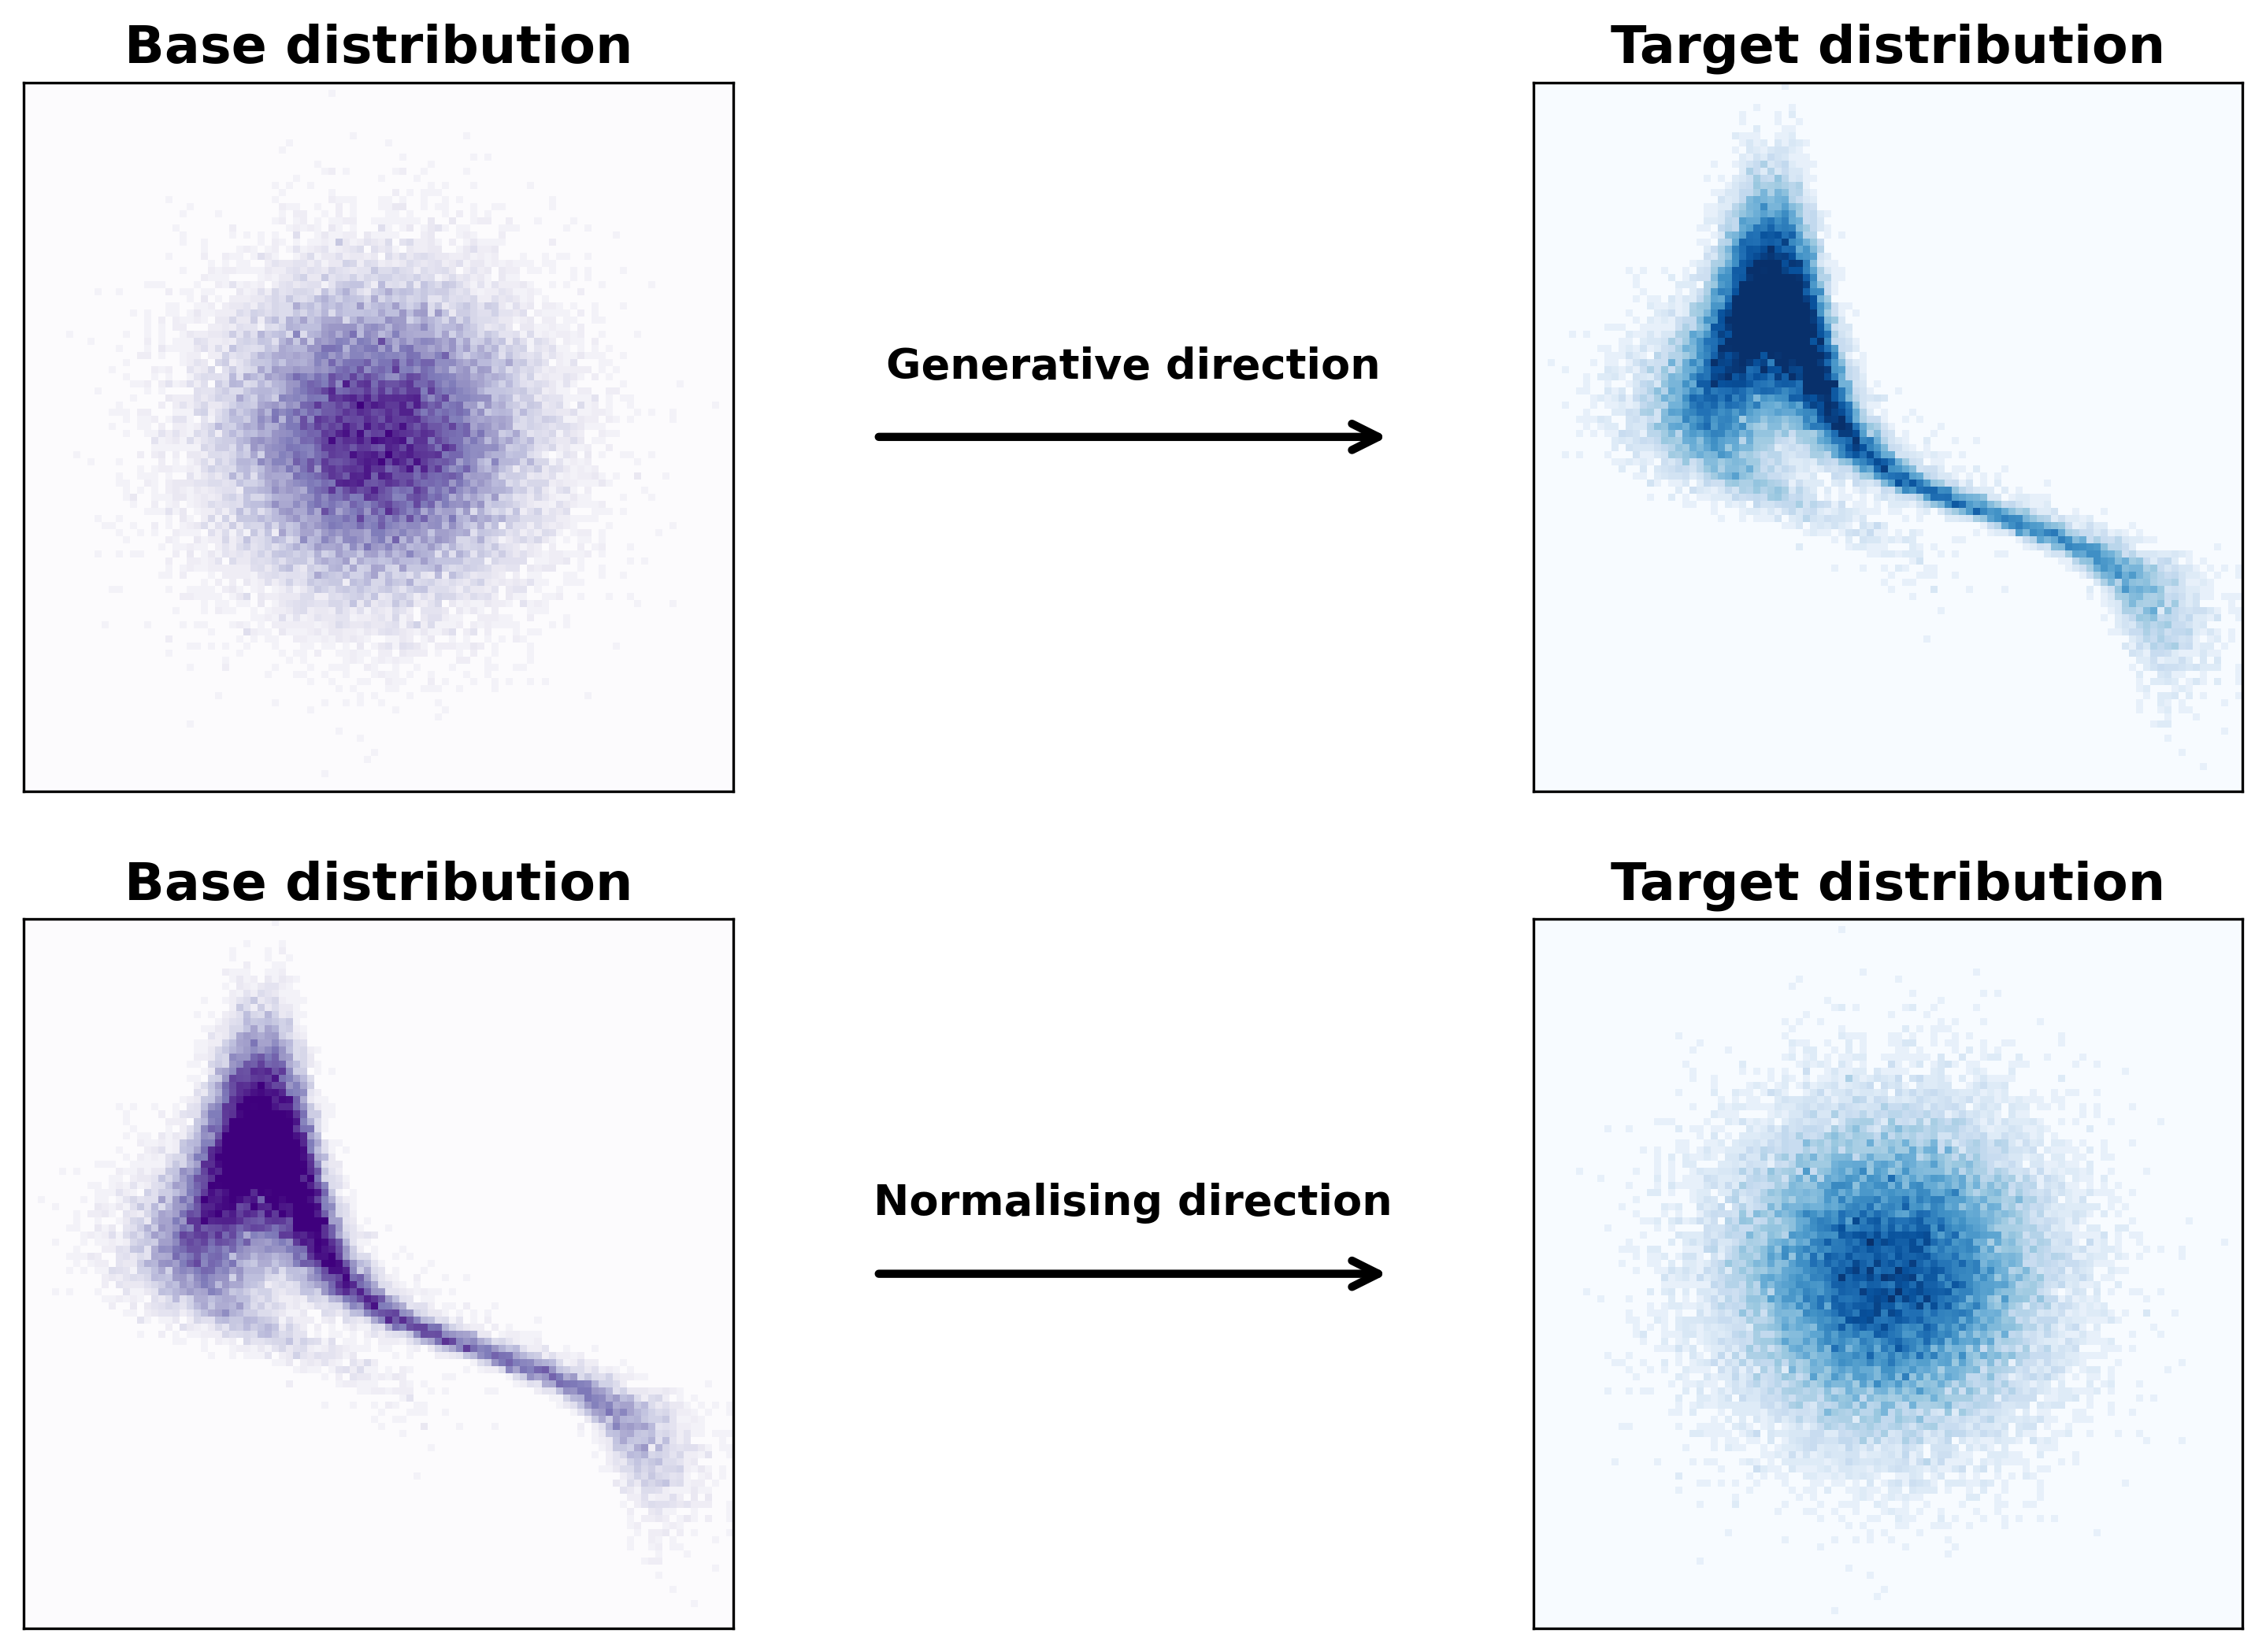

In [5]:
# Histogram-based view mirroring the arrow layout
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib import colors

assert 'tri_modal_forward' in globals() and 'tri_modal_inverse' in globals() and 'cfg' in globals(), \
    "Run the tri-modal flow cell first."

np.random.seed(7)
n = 40000
z = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], n)
y = tri_modal_forward(z, cfg)

num_lines = 80
line_extent = 30.0
points_per_line = 600
vals = np.linspace(-10, 10, num_lines)
line = np.linspace(-line_extent, line_extent, points_per_line)

fig = plt.figure(figsize=(15, 8.5), dpi = 300)
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.22, hspace=0.18)

view_lim = 4.5
alpha_grid = 0.3
cmap_base = plt.get_cmap('Purples')
cmap_flow = plt.get_cmap('Blues')
hist_kwargs_base = dict(bins=100, range=[[-view_lim, view_lim], [-view_lim, view_lim]], cmap=cmap_base)
hist_kwargs_flow = dict(bins=100, range=[[-view_lim, view_lim], [-view_lim, view_lim]], cmap=cmap_flow)

def draw_straight_grid(ax, color="#808080", alpha=0.6, lw=1.0):
    for t in vals:
        ax.plot([-line_extent, line_extent], [t, t], color, alpha=alpha, lw=lw, zorder=3)
    for t in vals:
        ax.plot([t, t], [-line_extent, line_extent], color, alpha=alpha, lw=lw, zorder=3)

def draw_warped_grid_forward(ax, color="#808080", alpha=0.75, lw=1.1):
    for t in vals:
        zl = np.column_stack([line, np.full_like(line, t)])
        yl = tri_modal_forward(zl, cfg)
        ax.plot(yl[:, 0], yl[:, 1], color, alpha=alpha, lw=lw, zorder=3)
    for t in vals:
        zl = np.column_stack([np.full_like(line, t), line])
        yl = tri_modal_forward(zl, cfg)
        ax.plot(yl[:, 0], yl[:, 1], color, alpha=alpha, lw=lw, zorder=3)

def draw_warped_grid_inverse(ax, color="#808080", alpha=0.75, lw=1.1, lr=False):
    if lr:
        vals = np.linspace(-10, 10, 80)
    for t in vals:
        yl = np.column_stack([line, np.full_like(line, t)])
        zl = tri_modal_inverse(yl, cfg)
        ax.plot(zl[:, 0], zl[:, 1], color, alpha=alpha, lw=lw, zorder=3)
    for t in vals:
        yl = np.column_stack([np.full_like(line, t), line])
        zl = tri_modal_inverse(yl, cfg)
        ax.plot(zl[:, 0], zl[:, 1], color, alpha=alpha, lw=lw, zorder=3)

norm = colors.PowerNorm(gamma=0.6)

ax_tl = fig.add_subplot(gs[0, 0])
ax_tl.hist2d(z[:, 0], z[:, 1], norm=norm, **hist_kwargs_base)
#draw_straight_grid(ax_tl, alpha=alpha_grid)
ax_tl.set_title('Base distribution')
ax_tl.set_xlim(-view_lim, view_lim); ax_tl.set_ylim(-view_lim, view_lim); ax_tl.set_aspect('equal'); ax_tl.grid(False)

ax_tr = fig.add_subplot(gs[0, 1])
ax_tr.hist2d(y[:, 0], y[:, 1], norm=norm, **hist_kwargs_flow)
#draw_warped_grid_forward(ax_tr, alpha=alpha_grid)
ax_tr.set_title('Target distribution')
ax_tr.set_xlim(-view_lim, view_lim); ax_tr.set_ylim(-view_lim, view_lim); ax_tr.set_aspect('equal'); ax_tr.grid(False)

ax_bl = fig.add_subplot(gs[1, 0])
ax_bl.hist2d(y[:, 0], y[:, 1], norm=norm, **hist_kwargs_base)
#draw_straight_grid(ax_bl, alpha=alpha_grid)
ax_bl.set_title('Base distribution')
ax_bl.set_xlim(-view_lim, view_lim); ax_bl.set_ylim(-view_lim, view_lim); ax_bl.set_aspect('equal'); ax_bl.grid(False)

ax_br = fig.add_subplot(gs[1, 1])
ax_br.hist2d(z[:, 0], z[:, 1], norm=norm, **hist_kwargs_flow)
#draw_warped_grid_inverse(ax_br, alpha=alpha_grid, lr = True)
ax_br.set_title('Target distribution')
ax_br.set_xlim(-view_lim, view_lim); ax_br.set_ylim(-view_lim, view_lim); ax_br.set_aspect('equal'); ax_br.grid(False)

for ax in (ax_tl, ax_tr, ax_bl, ax_br):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

y0_top_axes = ax_tl.transAxes.inverted().transform(ax_tl.transData.transform((0, 0)))[1]
y0_bot_axes = ax_bl.transAxes.inverted().transform(ax_bl.transData.transform((0, 0)))[1]

start_top_fig = np.array(fig.transFigure.inverted().transform(ax_tl.transAxes.transform((1.0, y0_top_axes))))
end_top_fig = np.array(fig.transFigure.inverted().transform(ax_tr.transAxes.transform((0.0, y0_top_axes))))
start_bot_fig = np.array(fig.transFigure.inverted().transform(ax_bl.transAxes.transform((1.0, y0_bot_axes))))
end_bot_fig = np.array(fig.transFigure.inverted().transform(ax_br.transAxes.transform((0.0, y0_bot_axes))))

pad = 0.02
start_top_fig[0] += pad
end_top_fig[0] -= pad
start_bot_fig[0] += pad
end_bot_fig[0] -= pad

def center_set_length(p0, p1, target_length):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    direction = p1 - p0
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0:
        return p0, p1
    unit = direction / norm_dir
    midpoint = 0.5 * (p0 + p1)
    half_vec = 0.5 * target_length * unit
    return midpoint - half_vec, midpoint + half_vec

arrow_fixed_length = 0.5 * (np.linalg.norm(end_top_fig - start_top_fig) + np.linalg.norm(end_bot_fig - start_bot_fig))
arrow_length_scale = 4.0
arrow_target_length = arrow_fixed_length * arrow_length_scale
if arrow_target_length <= 0:
    raise ValueError("arrow_target_length must be positive.")

start_top_fig, end_top_fig = center_set_length(start_top_fig, end_top_fig, arrow_target_length)
start_bot_fig, end_bot_fig = center_set_length(start_bot_fig, end_bot_fig, arrow_target_length)

arrow_kwargs = dict(arrowstyle='->', linewidth=2.5, color='black', mutation_scale=20)
fig.add_artist(FancyArrowPatch(start_top_fig, end_top_fig, transform=fig.transFigure, **arrow_kwargs))
fig.add_artist(FancyArrowPatch(start_bot_fig, end_bot_fig, transform=fig.transFigure, **arrow_kwargs))

mid_top = 0.5 * (start_top_fig + end_top_fig)
mid_bot = 0.5 * (start_bot_fig + end_bot_fig)
offset = 0.025
fig.text(mid_top[0], mid_top[1] + offset, 'Generative direction',
         ha='center', va='bottom', fontsize=13, fontweight='bold')
fig.text(mid_bot[0], mid_bot[1] + offset, 'Normalising direction',
         ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.show()

In [6]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime

def _fractional_precision(num_str: str) -> int:
    """
    Number of digits after the decimal point in a numeric string (ignores exponent).
    Used to decide which duplicate value is 'more precise'.
    """
    # strip leading sign and split exponent if any
    base = num_str.lstrip("+-").split("e")[0].split("E")[0]
    if "." in base:
        return len(base.split(".")[1])
    return 0

def plot_loss_for_thesis(
    log_path: str,
    *,
    ylim=None,
    xlim=None,
    savepath: str | None = None,
    use_symlog: bool = True,
    linthresh = 1e-3
):
    """
    Parse a training log and plot train/val loss with thesis-friendly aesthetics.
    - No LR curve.
    - If multiple loss values exist for the same epoch, keeps the most precise one.
    - Marks the best validation loss.
    - Extracts and displays total training time.

    Parameters
    ----------
    log_path : str
        Path to the .log file.
    ylim, xlim : tuple | None
        Optional y/x limits.
    savepath : str | None
        If provided, saves the figure to this path ('.pdf' recommended for the thesis).
    use_symlog : bool
        Use a symlog y-scale to handle negative/near-zero values gracefully.
    linthresh : float
        Linear threshold for symlog scale.
    """
    # --- Parse ---
    num_pat = r'([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)'
    epoch_pat = re.compile(r'Epoch\s+(\d+)\s*/\s*\d+')
    line_pat  = re.compile(
        rf'val_loss:\s*{num_pat}.*?loss:\s*{num_pat}.*?(?:MinusLogProbMetric:)?',
        re.IGNORECASE
    )
    timestamp_pat = re.compile(r'timestamp\s*=\s*(.+)')
    training_complete_pat = re.compile(r'Training completed', re.IGNORECASE)

    with open(log_path, "r") as f:
        lines = f.readlines()

    current_epoch = None
    start_time = None
    end_time = None
    
    # store per-epoch the best (most precise) values
    per_epoch = defaultdict(lambda: {"val": None, "val_prec": -1, "train": None, "train_prec": -1})

    for idx, raw in enumerate(lines):
        s = raw.strip()
        
        # Extract start timestamp
        if start_time is None:
            m_ts = timestamp_pat.search(s)
            if m_ts:
                try:
                    start_time = datetime.fromisoformat(m_ts.group(1).strip())
                except ValueError:
                    pass
        
        # Check for training completion and get its timestamp (line before or same line)
        m_complete = training_complete_pat.search(s)
        if m_complete and end_time is None:
            # Try to find timestamp in previous lines or extract from epoch line timing
            # For now, we'll look for the last epoch line to estimate end time
            # We'll extract it after the parsing loop
            pass
        
        m_epoch = epoch_pat.search(s)
        if m_epoch:
            current_epoch = int(m_epoch.group(1))

        if current_epoch is None:
            continue

        if "MinusLogProbMetric:" in s and "val_loss:" in s:
            m_vals = line_pat.search(s)
            if not m_vals:
                # Fallback: capture separately if spacing/order deviates
                m_val  = re.search(rf'val_loss:\s*{num_pat}', s, flags=re.IGNORECASE)
                m_tr   = re.search(rf'(?<!val_)loss:\s*{num_pat}', s, flags=re.IGNORECASE)
                if not (m_val and m_tr):
                    continue
                val_str = m_val.group(1)
                trn_str = m_tr.group(1)
            else:
                val_str = m_vals.group(1)
                trn_str = m_vals.group(2)

            # precision (more digits after the decimal -> more precise)
            p_val = _fractional_precision(val_str)
            p_trn = _fractional_precision(trn_str)

            # keep only if strictly more precise than what we have
            if p_val > per_epoch[current_epoch]["val_prec"]:
                per_epoch[current_epoch]["val"] = float(val_str)
                per_epoch[current_epoch]["val_prec"] = p_val
            if p_trn > per_epoch[current_epoch]["train_prec"]:
                per_epoch[current_epoch]["train"] = float(trn_str)
                per_epoch[current_epoch]["train_prec"] = p_trn

    # Try to estimate end time from log file modification time or last epoch
    # For more accuracy, we parse epoch timing information
    if start_time:
        # Find lines with epoch duration (e.g., "1249s/epoch")
        total_seconds = 0
        for raw in lines:
            # Look for patterns like "1249s/epoch" or similar
            m_time = re.search(r'(\d+)s\s*/\s*epoch', raw, re.IGNORECASE)
            if m_time:
                total_seconds += int(m_time.group(1))
        
        if total_seconds > 0:
            from datetime import timedelta
            end_time = start_time + timedelta(seconds=total_seconds)

    # build ordered series
    if not per_epoch:
        raise ValueError("No epochs parsed — check the log format or regex.")
    epochs = sorted(per_epoch.keys())
    val_losses = [per_epoch[e]["val"]   for e in epochs]
    trn_losses = [per_epoch[e]["train"] for e in epochs]

    # If some epochs miss a value (rare), filter them out consistently
    mask = [ (v is not None) and (t is not None) for v, t in zip(val_losses, trn_losses) ]
    epochs     = [e for e, keep in zip(epochs, mask) if keep]
    val_losses = [v for v, keep in zip(val_losses, mask) if keep]
    trn_losses = [t for t, keep in zip(trn_losses, mask) if keep]

    if not val_losses:
        raise ValueError("No validation losses parsed — check the log format or regex.")
    if not trn_losses:
        raise ValueError("No training losses parsed — check the log format or regex.")

    # --- Console summary ---
    print("="*70)
    print(f"Epochs parsed: {len(epochs)} (from {epochs[0]} to {epochs[-1]})")
    print(f"Min validation loss: {min(val_losses):.6f} at epoch {epochs[val_losses.index(min(val_losses))]}")
    print(f"Min training   loss: {min(trn_losses):.6f} at epoch {epochs[trn_losses.index(min(trn_losses))]}")
    
    # Display training time
    if start_time and end_time:
        duration = end_time - start_time
        total_hours = duration.total_seconds() / 3600
        print(f"\n📊 TRAINING TIME:")
        print(f"   Start:    {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   End:      {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Duration: {total_hours:.2f} hours ({duration.days} days, {duration.seconds//3600} hrs, {(duration.seconds%3600)//60} min)")
    elif start_time:
        print(f"\n📊 TRAINING START: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print("   (End time could not be determined from log)")
    print("="*70)

    # --- Plot (thesis-friendly cosmetics) ---
    # Compact figure aimed at single-column width in LaTeX (adjust if your template differs)
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "figure.dpi": 150,
    })

    fig, ax = plt.subplots(figsize=(6.0, 3.6),dpi=300)  # ~ single-column wide

    # Colors chosen to be print-friendly and consistent
    clr_trn = "#E3A86B"   # orange-ish for training
    clr_val = "#8172B2"   # purple-ish for validation
    
    ax.plot(epochs, val_losses, label="Validation loss",
            lw=1.8, 
            markersize=3.5, alpha=0.95, color=clr_val)
    ax.plot(epochs, trn_losses, label="Training loss",
            lw=1.6, 
            markersize=3.0, alpha=0.9,  color=clr_trn)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    if use_symlog:
        # Loss can become negative late in training; symlog shows both signs sensibly.
        ax.set_yscale("symlog", linthresh=linthresh)

    # Clean grid and spines
    ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    if ylim is not None: ax.set_ylim(ylim)
    if xlim is not None: ax.set_xlim(xlim)

    # Mark and annotate best validation
    vmin = min(val_losses)
    imin = val_losses.index(vmin)
    e_best = epochs[imin]
    ax.scatter([e_best], [vmin], s=30, zorder=5, edgecolor="none", color=clr_val, label = f"best val: {vmin:.3g} (ep. {e_best})")

    ax.legend(loc="best", frameon=True)
    
    # Add training time to title if available
    title = "Training vs Validation Loss"
    if start_time and end_time:
        duration_hrs = (end_time - start_time).total_seconds() / 3600
        title += f"\n(Training time: {duration_hrs:.1f} hours)"
    ax.set_title(title)

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
        print(f"Saved figure to: {savepath}")

    plt.show()


Epochs parsed: 80 (from 1 to 80)
Min validation loss: -0.497260 at epoch 80
Min training   loss: -0.496486 at epoch 80

📊 TRAINING TIME:
   Start:    2025-09-28 18:08:09
   End:      2025-09-29 21:39:35
   Duration: 27.52 hours (1 days, 3 hrs, 31 min)


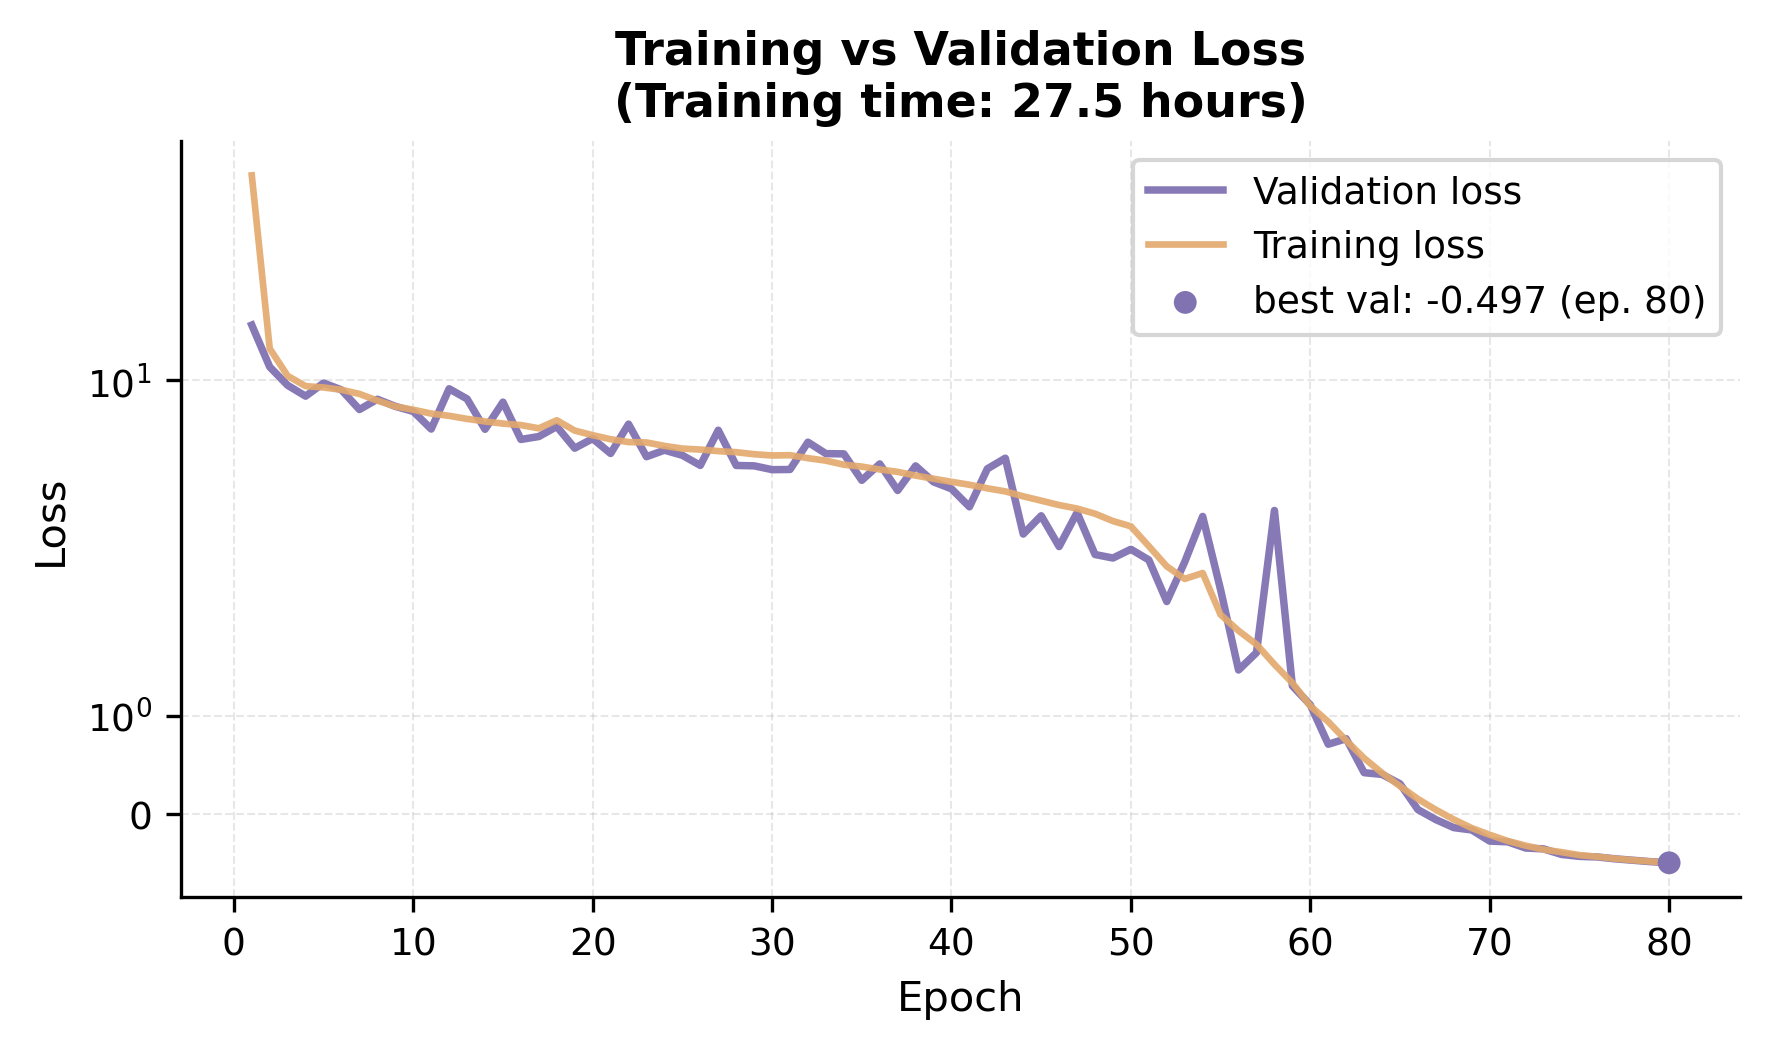

In [7]:
log_path = "./outputs/run_53/full_run_53.log"
plot_loss_for_thesis(log_path,
    ylim=None,
    xlim=None,
    savepath=None,
    use_symlog=True,
    linthresh=30e-1)

In [8]:
import re
import matplotlib.pyplot as plt
import numpy as np

def extract_epoch_times(log_path: str) -> dict:
    """
    Extract per-epoch training times from a log file.
    
    Parameters
    ----------
    log_path : str
        Path to the training log file.
        
    Returns
    -------
    dict
        Dictionary with keys:
        - 'epochs': list of epoch numbers
        - 'times_sec': list of times in seconds
        - 'times_hr': list of times in hours
        - 'total_hr': total training time in hours
        - 'mean_hr': mean epoch time in hours
        - 'std_hr': std of epoch times in hours
    """
    epoch_pat = re.compile(r'Epoch\s+(\d+)\s*/\s*\d+')
    epoch_time_pat = re.compile(r'(?<!\d)(\d+)s(?![a-zA-Z])')
    
    with open(log_path, "r") as f:
        lines = f.readlines()
    
    epoch_times = {}  # {epoch: seconds}
    current_epoch = None
    
    for idx, raw in enumerate(lines):
        s = raw.strip()
        
        # Find epoch number
        m_epoch = epoch_pat.search(s)
        if m_epoch:
            current_epoch = int(m_epoch.group(1))
            # Try to find epoch time on the same line
            m_time = epoch_time_pat.search(s)
            if m_time:
                epoch_times[current_epoch] = int(m_time.group(1))
            else:
                # Look ahead up to 3 lines for timing
                for j in range(idx, min(idx + 4, len(lines))):
                    m_time2 = epoch_time_pat.search(lines[j])
                    if m_time2:
                        epoch_times[current_epoch] = int(m_time2.group(1))
                        break
    
    if not epoch_times:
        raise ValueError(f"No epoch timing information found in {log_path}")
    
    epochs = sorted(epoch_times.keys())
    times_sec = [epoch_times[e]/60.0 for e in epochs]
    times_hr = [t / 60.0 for t in times_sec]
    
    return {
        'epochs': epochs,
        'times_sec': times_sec,
        'times_hr': times_hr,
        'total_hr': sum(times_sec) / 60.0,
        'mean_hr': np.mean(times_hr),
        'std_hr': np.std(times_hr)
    }


def compare_epoch_times(
    log_path1: str,
    log_path2: str,
    label1: str = "Run 1",
    label2: str = "Run 2",
    *,
    ylim=None,
    xlim=None,
    savepath: str | None = None
):
    """
    Compare training times per epoch between two runs.
    
    Parameters
    ----------
    log_path1 : str
        Path to first training log.
    log_path2 : str
        Path to second training log.
    label1 : str
        Label for first run.
    label2 : str
        Label for second run.
    ylim, xlim : tuple | None
        Optional axis limits.
    savepath : str | None
        If provided, saves the figure to this path.
    """
    # Extract epoch times from both logs
    data1 = extract_epoch_times(log_path1)
    data2 = extract_epoch_times(log_path2)
    
    # Print summary statistics in seconds
    total_sec1 = sum(data1['times_sec'])
    total_sec2 = sum(data2['times_sec'])
    mean_sec1 = np.mean(data1['times_sec'])
    mean_sec2 = np.mean(data2['times_sec'])
    std_sec1 = np.std(data1['times_sec'])
    std_sec2 = np.std(data2['times_sec'])
    
    print("="*70)
    print(f"{label1}:")
    print(f"  Epochs: {len(data1['epochs'])} ({data1['epochs'][0]} to {data1['epochs'][-1]})")
    print(f"  Total training time: {total_sec1:.0f} seconds ({data1['total_hr']:.2f} hours)")
    print(f"  Mean epoch time: {mean_sec1:.1f} ± {std_sec1:.1f} seconds")
    print()
    print(f"{label2}:")
    print(f"  Epochs: {len(data2['epochs'])} ({data2['epochs'][0]} to {data2['epochs'][-1]})")
    print(f"  Total training time: {total_sec2:.0f} seconds ({data2['total_hr']:.2f} hours)")
    print(f"  Mean epoch time: {mean_sec2:.1f} ± {std_sec2:.1f} seconds")
    print()
    
    # Compute difference
    time_diff_sec = total_sec2 - total_sec1
    time_diff_hr = data2['total_hr'] - data1['total_hr']
    pct_diff = 100 * time_diff_sec / total_sec1
    print(f"Difference: {time_diff_sec:+.0f} seconds ({time_diff_hr:+.2f} hours, {pct_diff:+.1f}%)")
    print("="*70)
    
    # --- Plotting ---
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "figure.dpi": 150,
    })
    
    fig, ax = plt.subplots(figsize=(6.0, 3.6), dpi=300)
    
    # Colors matching the loss plot style
    clr1 = "#8172B2"  # purple-ish
    clr2 = "#E3A86B"  # orange-ish
    
    # Plot in seconds instead of hours
    ax.plot(data1['epochs'], data1['times_sec'], 
            label=f"{label1} (total: {total_sec1:.0f}min)",
            lw=1.8, marker='o', markersize=3.5, alpha=0.95, color=clr1)
    ax.plot(data2['epochs'], data2['times_sec'], 
            label=f"{label2} (total: {total_sec2:.0f}min)",
            lw=1.6, marker='s', markersize=3.0, alpha=0.9, color=clr2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Epoch time [minutes]")
    ax.set_title(f"Training time per epoch comparison")
    
    # Clean grid and spines
    ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    if ylim is not None: ax.set_ylim(ylim)
    if xlim is not None: ax.set_xlim(xlim)
    
    ax.legend(loc="best", frameon=True)
    
    fig.tight_layout()
    
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
        print(f"Saved comparison figure to: {savepath}")
    
    plt.show()


batch size 30k:
  Epochs: 80 (1 to 80)
  Total training time: 1294 seconds (21.57 hours)
  Mean epoch time: 16.2 ± 0.4 seconds

batch size 10k:
  Epochs: 80 (1 to 80)
  Total training time: 1651 seconds (27.52 hours)
  Mean epoch time: 20.6 ± 0.3 seconds

Difference: +358 seconds (+5.96 hours, +27.6%)


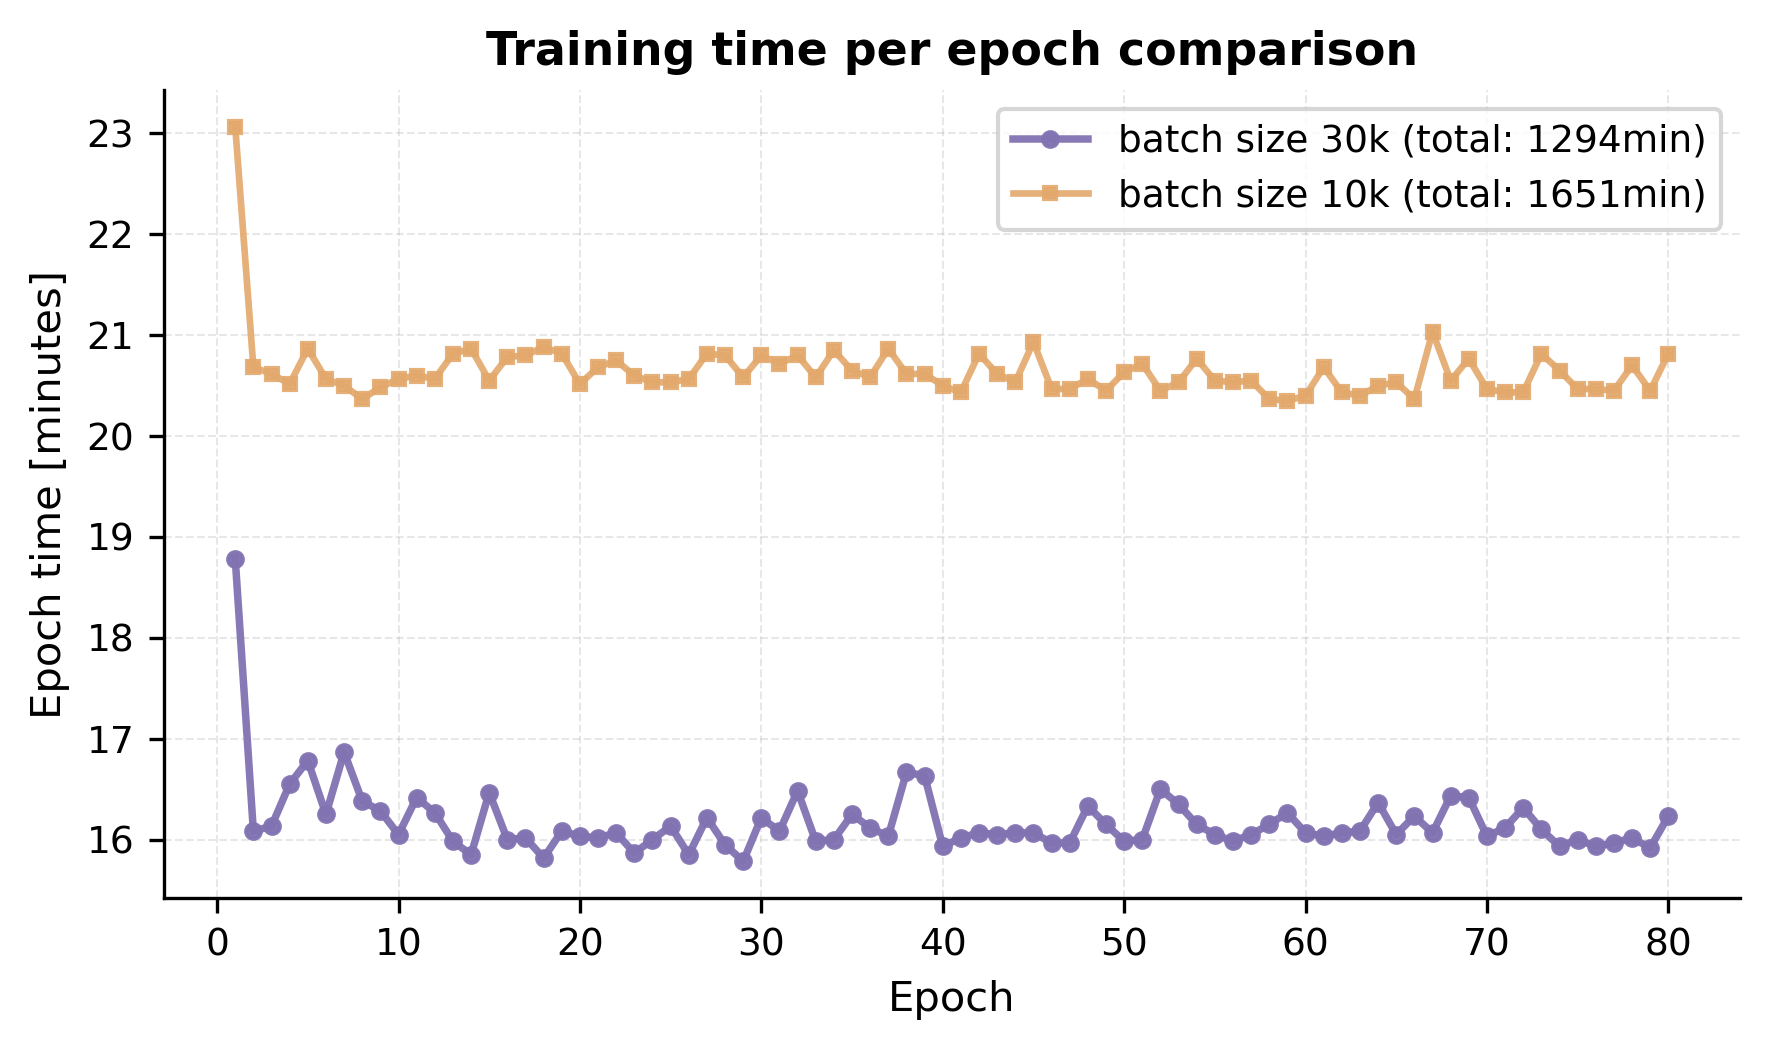

In [9]:
# Example: Compare training times between two runs
# Uncomment and modify paths as needed:

compare_epoch_times(
    log_path1="./outputs/run_40/10k_events_run.log",
    log_path2="./outputs/run_53/full_run_53.log",
    label1="batch size 30k",
    label2="batch size 10k",
    savepath=None
)


# Feature loading and centroid histograms
## Utilities to load eval features (centroids, RMS, energies) and plot thesis-ready histograms.

This section adds:
- `read_eval_centroids(h5_path)` to load centroid arrays (z̄, ā, r̄) for truth and model
- `plot_centroid_hist(...)` to overlay truth vs model as density histograms with means
- A quick usage example for the longitudinal centroid z̄

# RMS plots

In [10]:
def plot_rms_triptych(features: dict, bins: int = 70,
                      components = ('longitudinal','lateral','angular'),
                      figsize = (15,4.8), truth_color='#4C72B0', model_color='#DD8452',
                      range_pad=0.03, save_path: str | None = None, tight: bool = True,
                      x_scale='linear', y_scale='linear', x_linthresh=None, y_linthresh=None,
                      strict: bool = False):
    """Three-panel RMS plots with same styling and scale controls as centroids.
    Accepts global strings or dicts for x/y scale and linthresh (per component).

    If strict=False (default), components with missing datasets are skipped with a printed note.
    If strict=True, missing datasets raise a KeyError.
    """
    def _val(opt, comp):
        if isinstance(opt, dict): return opt.get(comp, next(iter(opt.values())) if len(opt) else None)
        return opt
    def _linth(opt, comp, default):
        if isinstance(opt, dict): return opt.get(comp, default)
        return opt if opt is not None else default

    key_t = {'longitudinal':'rms_long_true', 'lateral':'rms_lat_true', 'angular':'rms_a_true'}
    key_g = {'longitudinal':'rms_long_gen',  'lateral':'rms_lat_gen',  'angular':'rms_a_gen'}
    label = {'longitudinal':'RMS (longitudinal, mm)', 'lateral':'RMS (lateral, mm)', 'angular':'RMS (angular, rad)'}

    # Filter components by availability when strict=False
    comps_avail = []
    for comp in components:
        kt, kg = key_t[comp], key_g[comp]
        ok = (kt in features and kg in features and features.get(kt) is not None and features.get(kg) is not None)
        if ok:
            comps_avail.append(comp)
        elif strict:
            raise KeyError(f"Required datasets for '{comp}' missing. Available keys: {list(features.keys())}")
        else:
            print(f"[plot_rms_triptych] Skipping '{comp}' — dataset missing in features.")

    if not comps_avail:
        print('[plot_rms_triptych] No components available to plot.'); return {'components': []}

    fig, axes = plt.subplots(1, len(comps_avail), figsize=figsize, sharey=False)
    if len(comps_avail) == 1: axes = [axes]
    for ax, comp in zip(axes, comps_avail):
        t = features[key_t[comp]]; g = features[key_g[comp]]
        xmin = float(min(t.min(), g.min())); xmax = float(max(t.max(), g.max())); dx = xmax - xmin
        pad = range_pad * dx if dx>0 else 1.0; rng = (xmin - pad, xmax + pad)
        t_counts, edges = np.histogram(t, bins=bins, range=rng, density=True)
        g_counts, _     = np.histogram(g, bins=bins, range=rng, density=True)
        stairs_x = np.repeat(edges, 2)[1:-1]; stairs_y_t = np.repeat(t_counts, 2)
        ax.fill_between(stairs_x, stairs_y_t, step='post', color=truth_color, alpha=0.35, label='Truth')
        ax.step(edges[:-1], t_counts, where='post', color=truth_color, linewidth=1.2)
        ax.step(edges[:-1], g_counts, where='post', color=model_color, linewidth=2.0, label='Model')
        if len(t_counts):
            ax.hlines(t_counts[0], edges[0], edges[1], color=truth_color, linewidth=1.2)
            ax.hlines(t_counts[-1], edges[-2], edges[-1], color=truth_color, linewidth=1.2)
        if len(g_counts):
            ax.hlines(g_counts[0], edges[0], edges[1], color=model_color, linewidth=2.0)
            ax.hlines(g_counts[-1], edges[-2], edges[-1], color=model_color, linewidth=2.0)
        ax.set_xlabel(label[comp], fontsize=16)
        if ax is axes[0]: ax.set_ylabel('Density', fontsize=16)
        ax.grid(alpha=0.25)
        xs = _val(x_scale, comp); ys = _val(y_scale, comp)
        if xs == 'symlog':
            default_x_lt = max(1e-12, (xmax - xmin)*0.01)
            ax.set_xscale('symlog', linthresh=_linth(x_linthresh, comp, default_x_lt))
        elif xs != 'linear':
            raise ValueError(f"x_scale for {comp} must be 'linear' or 'symlog' (got {xs})")
        if ys == 'symlog':
            pos_vals = np.concatenate([t_counts[t_counts>0], g_counts[g_counts>0]])
            default_y_lt = pos_vals.min() if pos_vals.size else 1e-12
            ax.set_yscale('symlog', linthresh=_linth(y_linthresh, comp, default_y_lt))
        elif ys != 'linear':
            raise ValueError(f"y_scale for {comp} must be 'linear' or 'symlog' (got {ys})")
        ax.legend(frameon=False, fontsize=16, loc='best')
    #fig.suptitle('RMS Distributions', fontsize=16, y=1.02)
    if tight: fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    if 'enforce_min_fontsize' in globals():
        try: enforce_min_fontsize()
        except Exception: pass
    plt.show()
    return {'components': list(comps_avail), 'bins': int(bins)}


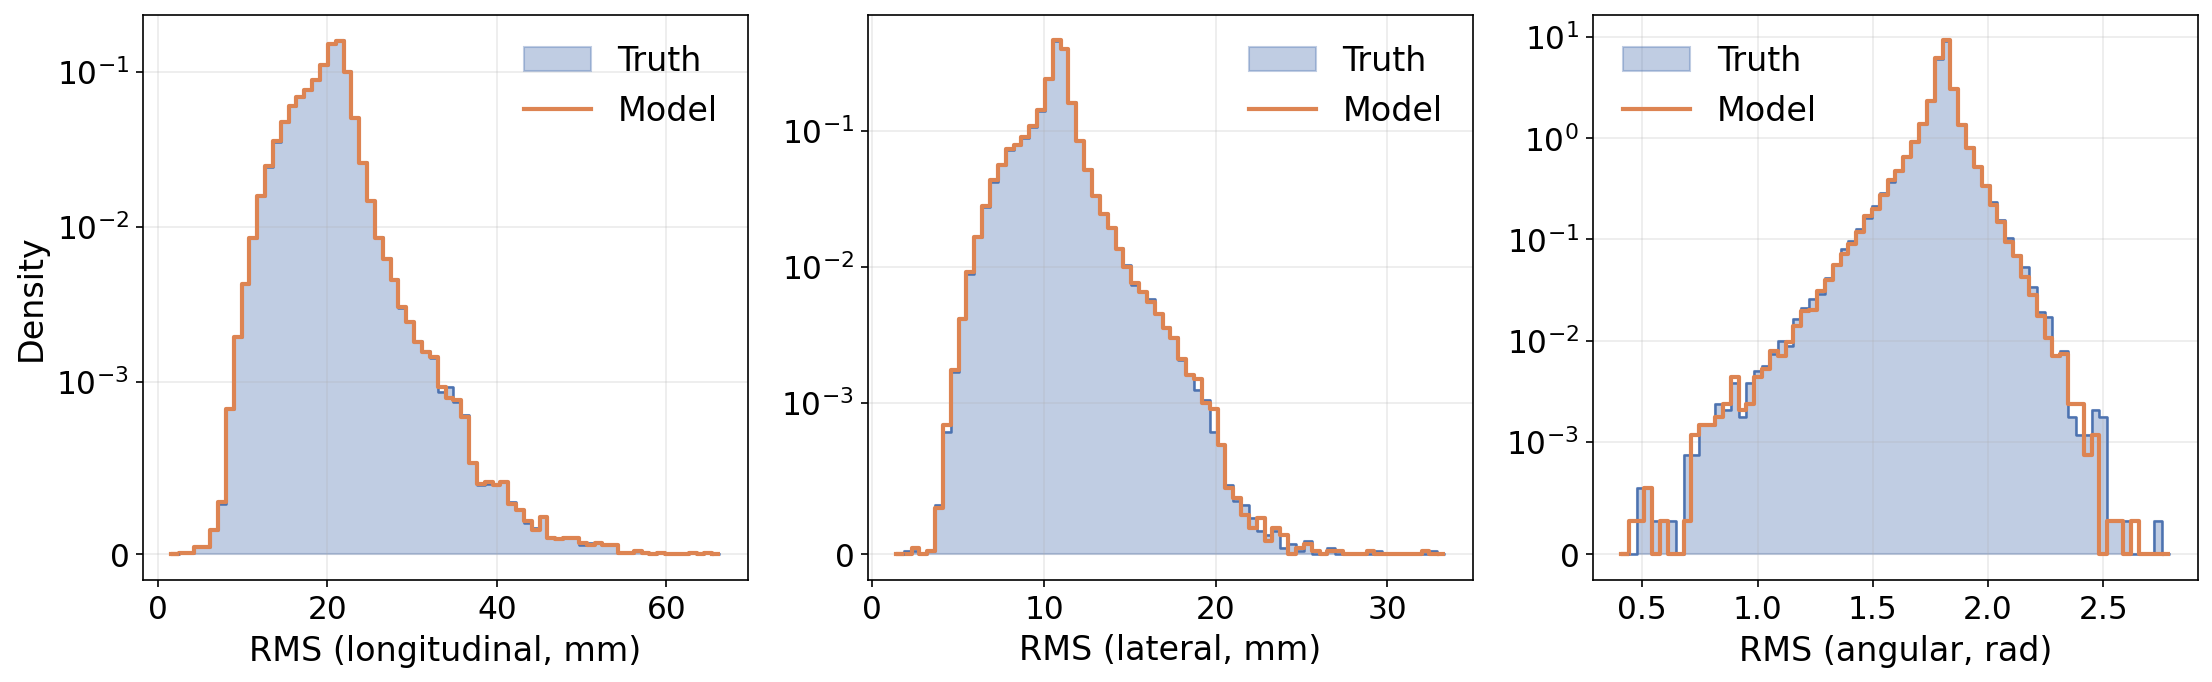

In [11]:
# Unified init cell: fonts + load + auto plot
features_path = "/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5"
if 'features_path' in globals() and os.path.exists(features_path):
    # Ensure fonts
    if 'set_thesis_fonts' in globals(): set_thesis_fonts(15)
    # Load
    feats = read_eval_centroids(features_path)
    # Auto-select components
    comps = []
    if feats.get('rms_long_true') is not None and feats.get('rms_long_gen') is not None: comps.append('longitudinal')
    if feats.get('rms_lat_true')  is not None and feats.get('rms_lat_gen')  is not None: comps.append('lateral')
    if feats.get('rms_a_true')    is not None and feats.get('rms_a_gen')    is not None: comps.append('angular')
    # Plot
    if comps:
        _ = plot_rms_triptych(feats, components=tuple(comps), bins=70, y_scale='symlog', y_linthresh=1e-3, strict=False)
    else:
        print('[init] No RMS components available to plot.')
else:
    print('[init] features_path not set or file missing.')

# centroid plots

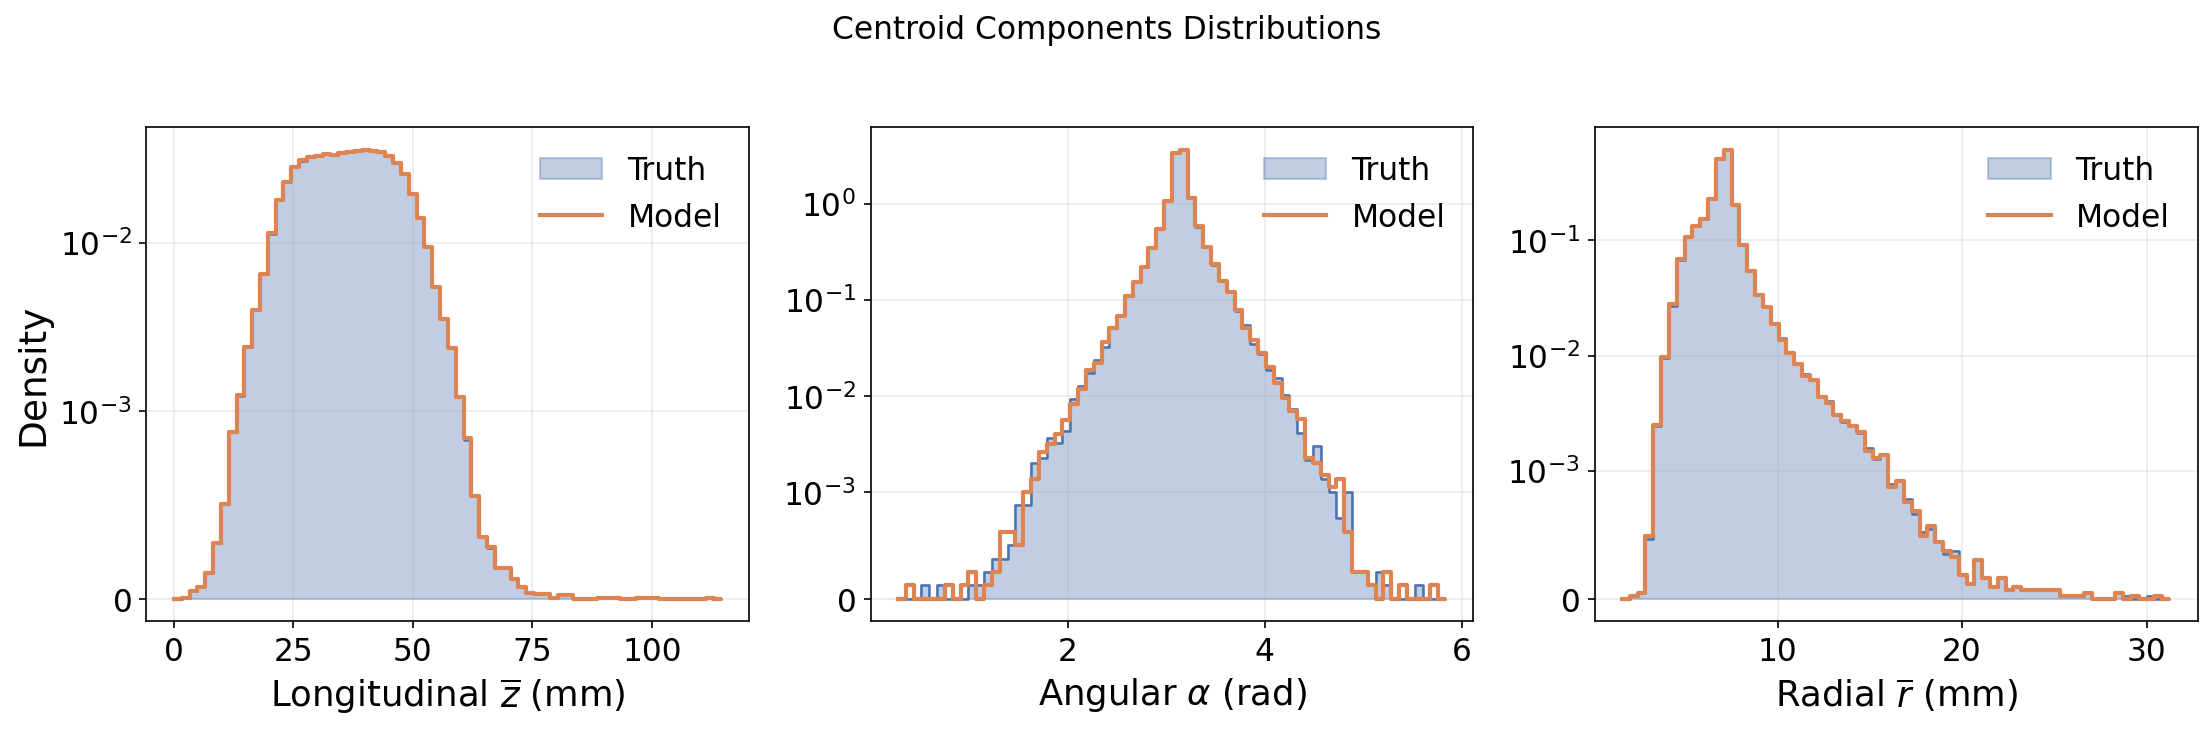

In [12]:
def plot_centroid_triptych(features: dict, bins: int = 70,
                             components = ('z','a','r'),
                             figsize = (15,4.8),
                             truth_color = '#4C72B0',
                             model_color = '#DD8452',
                             range_pad = 0.03,
                             save_path: str | None = None,
                             tight: bool = True,
                             # Axis scaling options (global or per-component dict)
                             x_scale = 'linear', y_scale = 'linear',
                             x_linthresh = None, y_linthresh = None):
    """Plot z̄, ā, r̄ centroid component distributions in one horizontal figure.

    Truth: filled density histogram; Model: step line.
    Supports linear or symlog axes. For per-component customization pass dictionaries:
        x_scale={'z':'symlog','a':'linear','r':'symlog'}
        x_linthresh={'z':1.0,'r':0.5}
    Missing dict keys fall back to global defaults.
    """
    def _val(opt, comp):
        if isinstance(opt, dict):
            return opt.get(comp, next(iter(opt.values())) if len(opt) else None)
        return opt
    def _linth(opt, comp, default):
        if isinstance(opt, dict):
            return opt.get(comp, default)
        return opt if opt is not None else default

    idx_map = {'z':0,'a':1,'r':2}
    labels = {'z':r'Longitudinal $\overline{z}$ (mm)', 'a':r'Angular $\alpha$ (rad)', 'r':r'Radial $\overline{r}$ (mm)'}
    data_t = features['centroid_true']; data_g = features['centroid_gen']
    ncomp = len(components)
    fig, axes = plt.subplots(1, ncomp, figsize=figsize, sharey=False)
    if ncomp == 1: axes = [axes]
    for ax, comp in zip(axes, components):
        if comp not in idx_map: raise ValueError(f"Unknown component {comp}")
        i = idx_map[comp]; ct = data_t[:, i]; cg = data_g[:, i]
        xmin = min(ct.min(), cg.min()); xmax = max(ct.max(), cg.max()); dx = xmax - xmin
        pad = range_pad * dx if dx>0 else 1.0; rng = (xmin - pad, xmax + pad)
        t_counts, edges = np.histogram(ct, bins=bins, range=rng, density=True)
        g_counts, _     = np.histogram(cg, bins=bins, range=rng, density=True)
        stairs_x = np.repeat(edges, 2)[1:-1]; stairs_y_t = np.repeat(t_counts, 2)
        ax.fill_between(stairs_x, stairs_y_t, step='post', color=truth_color, alpha=0.35, label='Truth')
        ax.step(edges[:-1], t_counts, where='post', color=truth_color, linewidth=1.2)
        ax.step(edges[:-1], g_counts, where='post', color=model_color, linewidth=2.0, label='Model')
        if len(t_counts):
            ax.hlines(t_counts[0], edges[0], edges[1], color=truth_color, linewidth=1.2)
            ax.hlines(t_counts[-1], edges[-2], edges[-1], color=truth_color, linewidth=1.2)
        if len(g_counts):
            ax.hlines(g_counts[0], edges[0], edges[1], color=model_color, linewidth=2.0)
            ax.hlines(g_counts[-1], edges[-2], edges[-1], color=model_color, linewidth=2.0)
        ax.set_xlabel(labels[comp], fontsize=17)
        if ax is axes[0]: ax.set_ylabel('Density', fontsize=18)
        ax.grid(alpha=0.25)
        xs = _val(x_scale, comp); ys = _val(y_scale, comp)
        if xs == 'symlog':
            default_x_lt = max(1e-12, (xmax - xmin)*0.01)
            ax.set_xscale('symlog', linthresh=_linth(x_linthresh, comp, default_x_lt))
        elif xs != 'linear':
            raise ValueError(f"x_scale for {comp} must be 'linear' or 'symlog' (got {xs})")
        if ys == 'symlog':
            pos_vals = np.concatenate([t_counts[t_counts>0], g_counts[g_counts>0]])
            default_y_lt = pos_vals.min() if pos_vals.size else 1e-12
            ax.set_yscale('symlog', linthresh=_linth(y_linthresh, comp, default_y_lt))
        elif ys != 'linear':
            raise ValueError(f"y_scale for {comp} must be 'linear' or 'symlog' (got {ys})")
        ax.legend(frameon=False, fontsize=15, loc='best')
    fig.suptitle('Centroid Components Distributions', fontsize=15, y=1.02)
    if tight: fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    return {'components': list(components), 'bins': int(bins)}

# Triptych symlog example (custom per-component scaling)
try:
    if 'features_path' in globals() and os.path.exists(features_path):
        if '_feats' not in globals(): _feats = read_eval_centroids(features_path)
        _ = plot_centroid_triptych(_feats, bins=70,
                                   x_scale={'z':'linear','a':'linear','r':'linear'},
                                   y_scale='symlog',
                                   x_linthresh={'z':10,'r':2.0, 'a':1e-3},
                                   y_linthresh=1e-3)
    else:
        print('Feature file missing; triptych symlog example skipped.')
except Exception as e:
    print('[triptych symlog example] Failed:', e)

# full shower

In [13]:
def load_full_showers(
    results_h5: str,
    *,
    n_events: int = 100_000,
    ncoarse_per_event = None,  # if None, auto-detect from file attrs (V)
    dtype: str | np.dtype = "float32",
    events_chunk: int = 1024,              # assemble this many events per streaming chunk
    verbose: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Assemble full calorimeter showers from row-wise (coarse, fine-slice) segments.

        Expects datasets:
            /truth_E : [N_rows, Df_per_coarse]   where N_rows = total_events * ncoarse_per_event
            /model_E : [N_rows, Df_per_coarse]

        For Mode A, Df_per_coarse = 10 and ncoarse_per_event = 648 → full shower has 6480 voxels.

    Returns
    -------
    input_true : (n_events, ncoarse_per_event * Df_per_coarse) float32
    input_gen  : (n_events, ncoarse_per_event * Df_per_coarse) float32
    """
    path = Path(results_h5)
    if not path.exists():
        raise FileNotFoundError(f"Input file not found: {path}")

    with h5py.File(path, "r") as f:
        if "/truth_E" not in f or "/model_E" not in f:
            raise KeyError("Expected '/truth_E' and '/model_E' in results file.")

        ds_true = f["/truth_E"]   # [N_rows, Df_per_coarse]
        ds_gen  = f["/model_E"]   # [N_rows, Df_per_coarse]
        N_rows, Df_per = ds_true.shape
        if ds_gen.shape != (N_rows, Df_per):
            raise ValueError("Shape mismatch between '/truth_E' and '/model_E'.")

        # --- Robust auto-detection of ncoarse_per_event ---
        if ncoarse_per_event is None:
            attr_V = f.attrs.get("V", None)  # should be nz*na*nr = 648 for Mode A
            candidate_from_rows = None
            if N_rows % n_events == 0:  # user requested n_events (default 100k)
                candidate_from_rows = N_rows // n_events
            # Build list of plausible candidates
            candidates = []
            if attr_V is not None:
                candidates.append(int(attr_V))
            if candidate_from_rows is not None:
                candidates.append(int(candidate_from_rows))
            # Common mistaken stored value: attr_V * Df_per (e.g. 648*10=6480)
            if attr_V is not None and attr_V % Df_per == 0:
                wrong_mult = int(attr_V * Df_per)
                if N_rows % wrong_mult == 0:  # treat as potential mis-specified
                    candidates.append(int(attr_V))  # keep correct one
            # If attribute absent, try to infer by factoring N_rows.
            if not candidates:
                # Heuristic: try typical geometry 648 first
                if N_rows % 648 == 0:
                    candidates.append(648)
                # fallback: scan small divisors up to 2000 and pick one near 648 if exists
                for d in (576, 600, 640, 648, 672, 720):
                    if N_rows % d == 0:
                        candidates.append(d)
                if not candidates:
                    raise ValueError(
                        f"Cannot infer ncoarse_per_event: no attrs 'V', and no typical divisor fits N_rows={N_rows}."
                    )
            # Choose candidate closest to 648 (expected) if multiple
            ncoarse_per_event = min(candidates, key=lambda c: abs(c - 648))
            if verbose:
                print(f"[load_full_showers] Inferred ncoarse_per_event={ncoarse_per_event} (candidates={candidates}).")
        # Detect common error: using 10x the correct value (6480)
        if ncoarse_per_event >= 5000 and ncoarse_per_event % 10 == 0:
            suspected = ncoarse_per_event // 10
            if N_rows % suspected == 0 and suspected in (648, 576, 640, 672, 720):
                if verbose:
                    print(f"[load_full_showers] Warning: ncoarse_per_event={ncoarse_per_event} looks like 10x too large; correcting to {suspected}.")
                ncoarse_per_event = suspected

        # Total events available in the file (must be an integer multiple of ncoarse_per_event).
        if N_rows % ncoarse_per_event != 0:
            raise ValueError(
                f"N_rows={N_rows} not divisible by inferred ncoarse_per_event={ncoarse_per_event}. Df_per={Df_per}."
            )
        total_events = N_rows // ncoarse_per_event
        if verbose:
            print(f"[load_full_showers] total_events={total_events}, full_dimension={ncoarse_per_event*Df_per}")

        # Cap n_events to what's available
        n = min(n_events, total_events)
        if verbose:
            print(
                f"Assembling {n} / {total_events} events "
                f"(rows={N_rows}, ncoarse={ncoarse_per_event}, Df_per={Df_per} → full D={ncoarse_per_event*Df_per}) "
                f"from {path.name}"
            )

        full_D = ncoarse_per_event * Df_per
        out_true = np.empty((n, full_D), dtype=dtype)
        out_gen  = np.empty((n, full_D), dtype=dtype)

        # Stream in blocks of whole events
        ev = 0
        while ev < n:
            k = min(events_chunk, n - ev)  # events in this chunk
            # Corresponding row slice (each event contributes ncoarse_per_event rows)
            i0 = ev * ncoarse_per_event
            i1 = (ev + k) * ncoarse_per_event

            # Read contiguous rows for these k events
            block_true = ds_true[i0:i1, :]   # shape = (k * ncoarse_per_event, Df_per)
            block_gen  = ds_gen[i0:i1, :]

            # Reshape to (k, ncoarse, Df_per) then flatten to (k, ncoarse*Df_per)
            block_true = block_true.reshape(k, ncoarse_per_event, Df_per).astype(dtype, copy=False)
            block_gen  = block_gen.reshape(k, ncoarse_per_event, Df_per).astype(dtype, copy=False)

            out_true[ev:ev+k, :] = block_true.reshape(k, full_D)
            out_gen[ev:ev+k, :]  = block_gen.reshape(k, full_D)

            ev += k
            if verbose:
                print(f"  -> assembled {ev}/{n} events")

    return out_true, out_gen

In [14]:
input_true, input_gen = load_full_showers(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    # ncoarse_per_event left as None → auto-detected from file attrs (V)
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)
print("shape of the input: ",input_true.shape, input_gen.shape, input_true.dtype)

shape of the input:  (100000, 6480) (100000, 6480) float32


In [15]:
input_true_flat = np.asarray(input_true.copy()).reshape(-1)
input_gen_flat  = np.asarray(input_gen.copy()).reshape(-1)
input_gen_flat.shape

(648000000,)

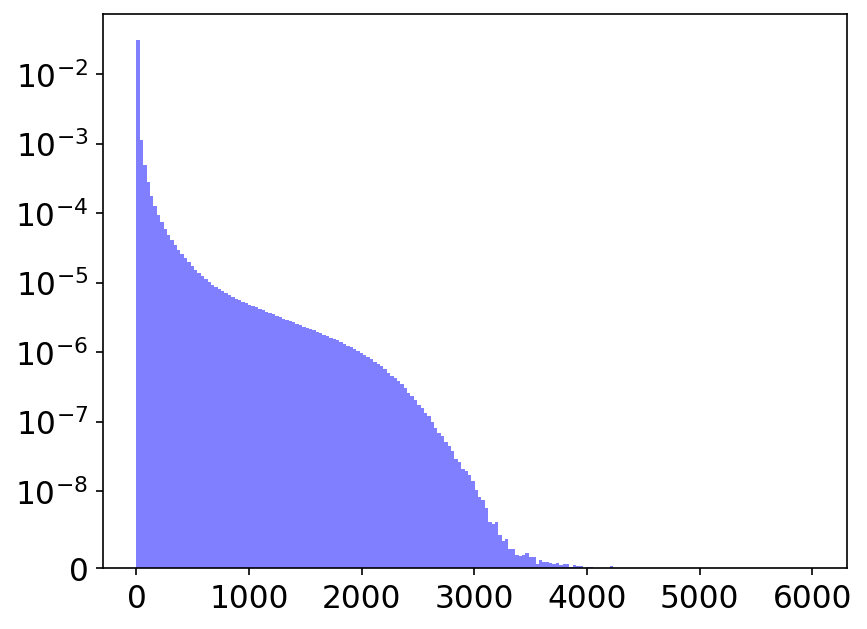

In [16]:
input_true_flat[input_true_flat != 0]

plt.hist(input_true_flat, bins=200, alpha=0.5, label='Truth', color='blue', density=True)
plt.yscale('symlog', linthresh=1e-8)
plt.show()

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from typing import Sequence, Optional, Union

def plot_voxel_histograms_1d(
    input_true: np.ndarray,
    input_gen:  np.ndarray,
    *,
    dims: Optional[Sequence[int]] = None,   # explicit voxel indices to plot
    k: int = 6,                              # how many to plot if dims=None
    random: bool = False,                    # if dims=None, choose random k
    seed: Optional[int] = None,              # RNG seed when random=True
    ncols: int = 3,                          # subplots per row
    bins: int = 70,
    figsize: tuple = (15, 4.8),
    truth_color: str = '#4C72B0',
    model_color: str = '#DD8452',
    range_pad: float = 0.03,
    tight: bool = True,
    save_path: Optional[str] = None,
    # Axis scaling options (global or per-dimension dict)
    x_scale: Union[str, dict] = 'linear',    # 'linear' or 'symlog' or dict {dim: 'symlog', ...}
    y_scale: Union[str, dict] = 'linear',
    x_linthresh: Optional[Union[float, dict]] = None,
    y_linthresh: Optional[Union[float, dict]] = None,
    sharey: bool = False
):
    """
    Compare 1D energy distributions for selected fine voxels (columns) of
    input_true vs input_gen using density histograms.

    Styling:
      - Truth: filled density histogram + thin step outline
      - Model: step line (thicker)
      - Grid with alpha=0.25
      - Linear or symlog axes (global or per-dimension)

    Parameters
    ----------
    input_true, input_gen : arrays with shape (N, D) – typically (100_000, 6480)
    dims : list of voxel indices to plot. If None, uses first k (or random k if random=True).
    k : number of voxels to plot when dims=None
    random : choose k random distinct indices when dims=None
    seed : RNG seed used when random=True
    ncols : number of panels per row
    bins : histogram bins
    figsize : figure size for a single row; height grows with number of rows
    truth_color, model_color : colors
    range_pad : fractional padding of the [min, max] range
    tight : tight_layout
    save_path : optional path to save the figure
    x_scale, y_scale : 'linear' | 'symlog' or dict mapping dim->scale
    x_linthresh, y_linthresh : symlog linthresh (global or per-dimension dict)
    sharey : share y axis across panels
    """

    # --- validations ---
    if input_true.shape != input_gen.shape:
        raise ValueError(f"Shape mismatch: true {input_true.shape} vs gen {input_gen.shape}")
    if input_true.ndim != 2:
        raise ValueError("Inputs must be 2D arrays (N, D).")
    N, D = input_true.shape
    if D == 0:
        raise ValueError("No features to plot (D=0).")

    # --- dimension selection ---
    if dims is None:
        kk = min(k, D)
        if random:
            rng = np.random.default_rng(seed)
            dims = rng.choice(D, size=kk, replace=False).tolist()
        else:
            dims = list(range(kk))
    else:
        dims = list(dims)
        for d in dims:
            if d < 0 or d >= D:
                raise IndexError(f"Requested dim {d} is out of bounds for D={D}")

    nplots = len(dims)
    if nplots == 0:
        raise ValueError("No dimensions selected to plot.")

    # helpers to support global or per-dimension dict options
    def _val(opt, dim):
        if isinstance(opt, dict):
            # if dict provided but missing dim key, use the first value (or fallback to 'linear')
            return opt.get(dim, next(iter(opt.values())) if len(opt) else 'linear')
        return opt

    def _linth(opt, dim, default):
        if isinstance(opt, dict):
            return opt.get(dim, default)
        return opt if opt is not None else default

    # layout
    ncols = max(1, int(ncols))
    nrows = int(ceil(nplots / ncols))
    # Scale height with rows to keep aspect pleasant
    row_h = figsize[1]
    fig_w = figsize[0]
    fig_h = max(3.0, row_h * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharey=sharey)
    axes = np.array(axes).reshape(-1) if nrows * ncols > 1 else np.array([axes])

    # actual plotting
    for ax, dim in zip(axes[:nplots], dims):
        t = input_true[:, dim]
        g = input_gen[:, dim]

        # range with padding; handle degenerate case
        xmin = float(np.nanmin([t.min(), g.min()]))
        xmax = float(np.nanmax([t.max(), g.max()]))
        dx = xmax - xmin
        pad = range_pad * dx if dx > 0 else 1.0
        rng = (xmin - pad, xmax + pad)

        # density histograms on the same edges
        t_counts, edges = np.histogram(t, bins=bins, range=rng, density=True)
        g_counts, _     = np.histogram(g, bins=bins, range=rng, density=True)

        # prepare stairs-like arrays for fill_between (Truth)
        stairs_x = np.repeat(edges, 2)[1:-1]
        stairs_y_t = np.repeat(t_counts, 2)

        # draw truth: filled area + thin outline (where='post' style)
        ax.fill_between(stairs_x, stairs_y_t, step='post', color=truth_color, alpha=0.35, label='Truth')
        ax.step(edges[:-1], t_counts, where='post', color=truth_color, linewidth=1.2)

        # draw model: thick step
        ax.step(edges[:-1], g_counts, where='post', color=model_color, linewidth=2.0, label='Model')

        # close the first/last bin visually (matching your previous style)
        if len(t_counts):
            ax.hlines(t_counts[0], edges[0], edges[1], color=truth_color, linewidth=1.2)
            ax.hlines(t_counts[-1], edges[-2], edges[-1], color=truth_color, linewidth=1.2)
        if len(g_counts):
            ax.hlines(g_counts[0], edges[0], edges[1], color=model_color, linewidth=2.0)
            ax.hlines(g_counts[-1], edges[-2], edges[-1], color=model_color, linewidth=2.0)

        # labels & grid
        ax.set_title(f'Voxel {dim}', fontsize=13)
        ax.set_xlabel('Energy (MeV)', fontsize=14)
        if ax is axes[0] or not sharey:
            ax.set_ylabel('Density', fontsize=14)
        ax.grid(alpha=0.25)

        # axis scales
        xs = _val(x_scale, dim)
        ys = _val(y_scale, dim)
        if xs == 'symlog':
            # default x linthresh: ~1% of data span or tiny positive
            default_x_lt = max(1e-12, (xmax - xmin) * 0.01)
            ax.set_xscale('symlog', linthresh=_linth(x_linthresh, dim, default_x_lt))
        elif xs != 'linear':
            raise ValueError(f"x_scale must be 'linear' or 'symlog' (got {xs})")

        if ys == 'symlog':
            pos_vals = np.concatenate([t_counts[t_counts > 0], g_counts[g_counts > 0]])
            default_y_lt = float(pos_vals.min()) if pos_vals.size else 1e-12
            ax.set_yscale('symlog', linthresh=_linth(y_linthresh, dim, default_y_lt))
        elif ys != 'linear':
            raise ValueError(f"y_scale must be 'linear' or 'symlog' (got {ys})")

        ax.legend(frameon=False, fontsize=12, loc='best')

    # hide any unused axes
    for ax in axes[nplots:]:
        ax.axis('off')

    fig.suptitle('Fine-Voxel Energy Distributions: Truth vs Model', fontsize=16, y=0.995)
    if tight:
        fig.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')

    plt.show()
    return {
        'dims': dims,
        'bins': int(bins),
        'nrows': nrows,
        'ncols': ncols
    }


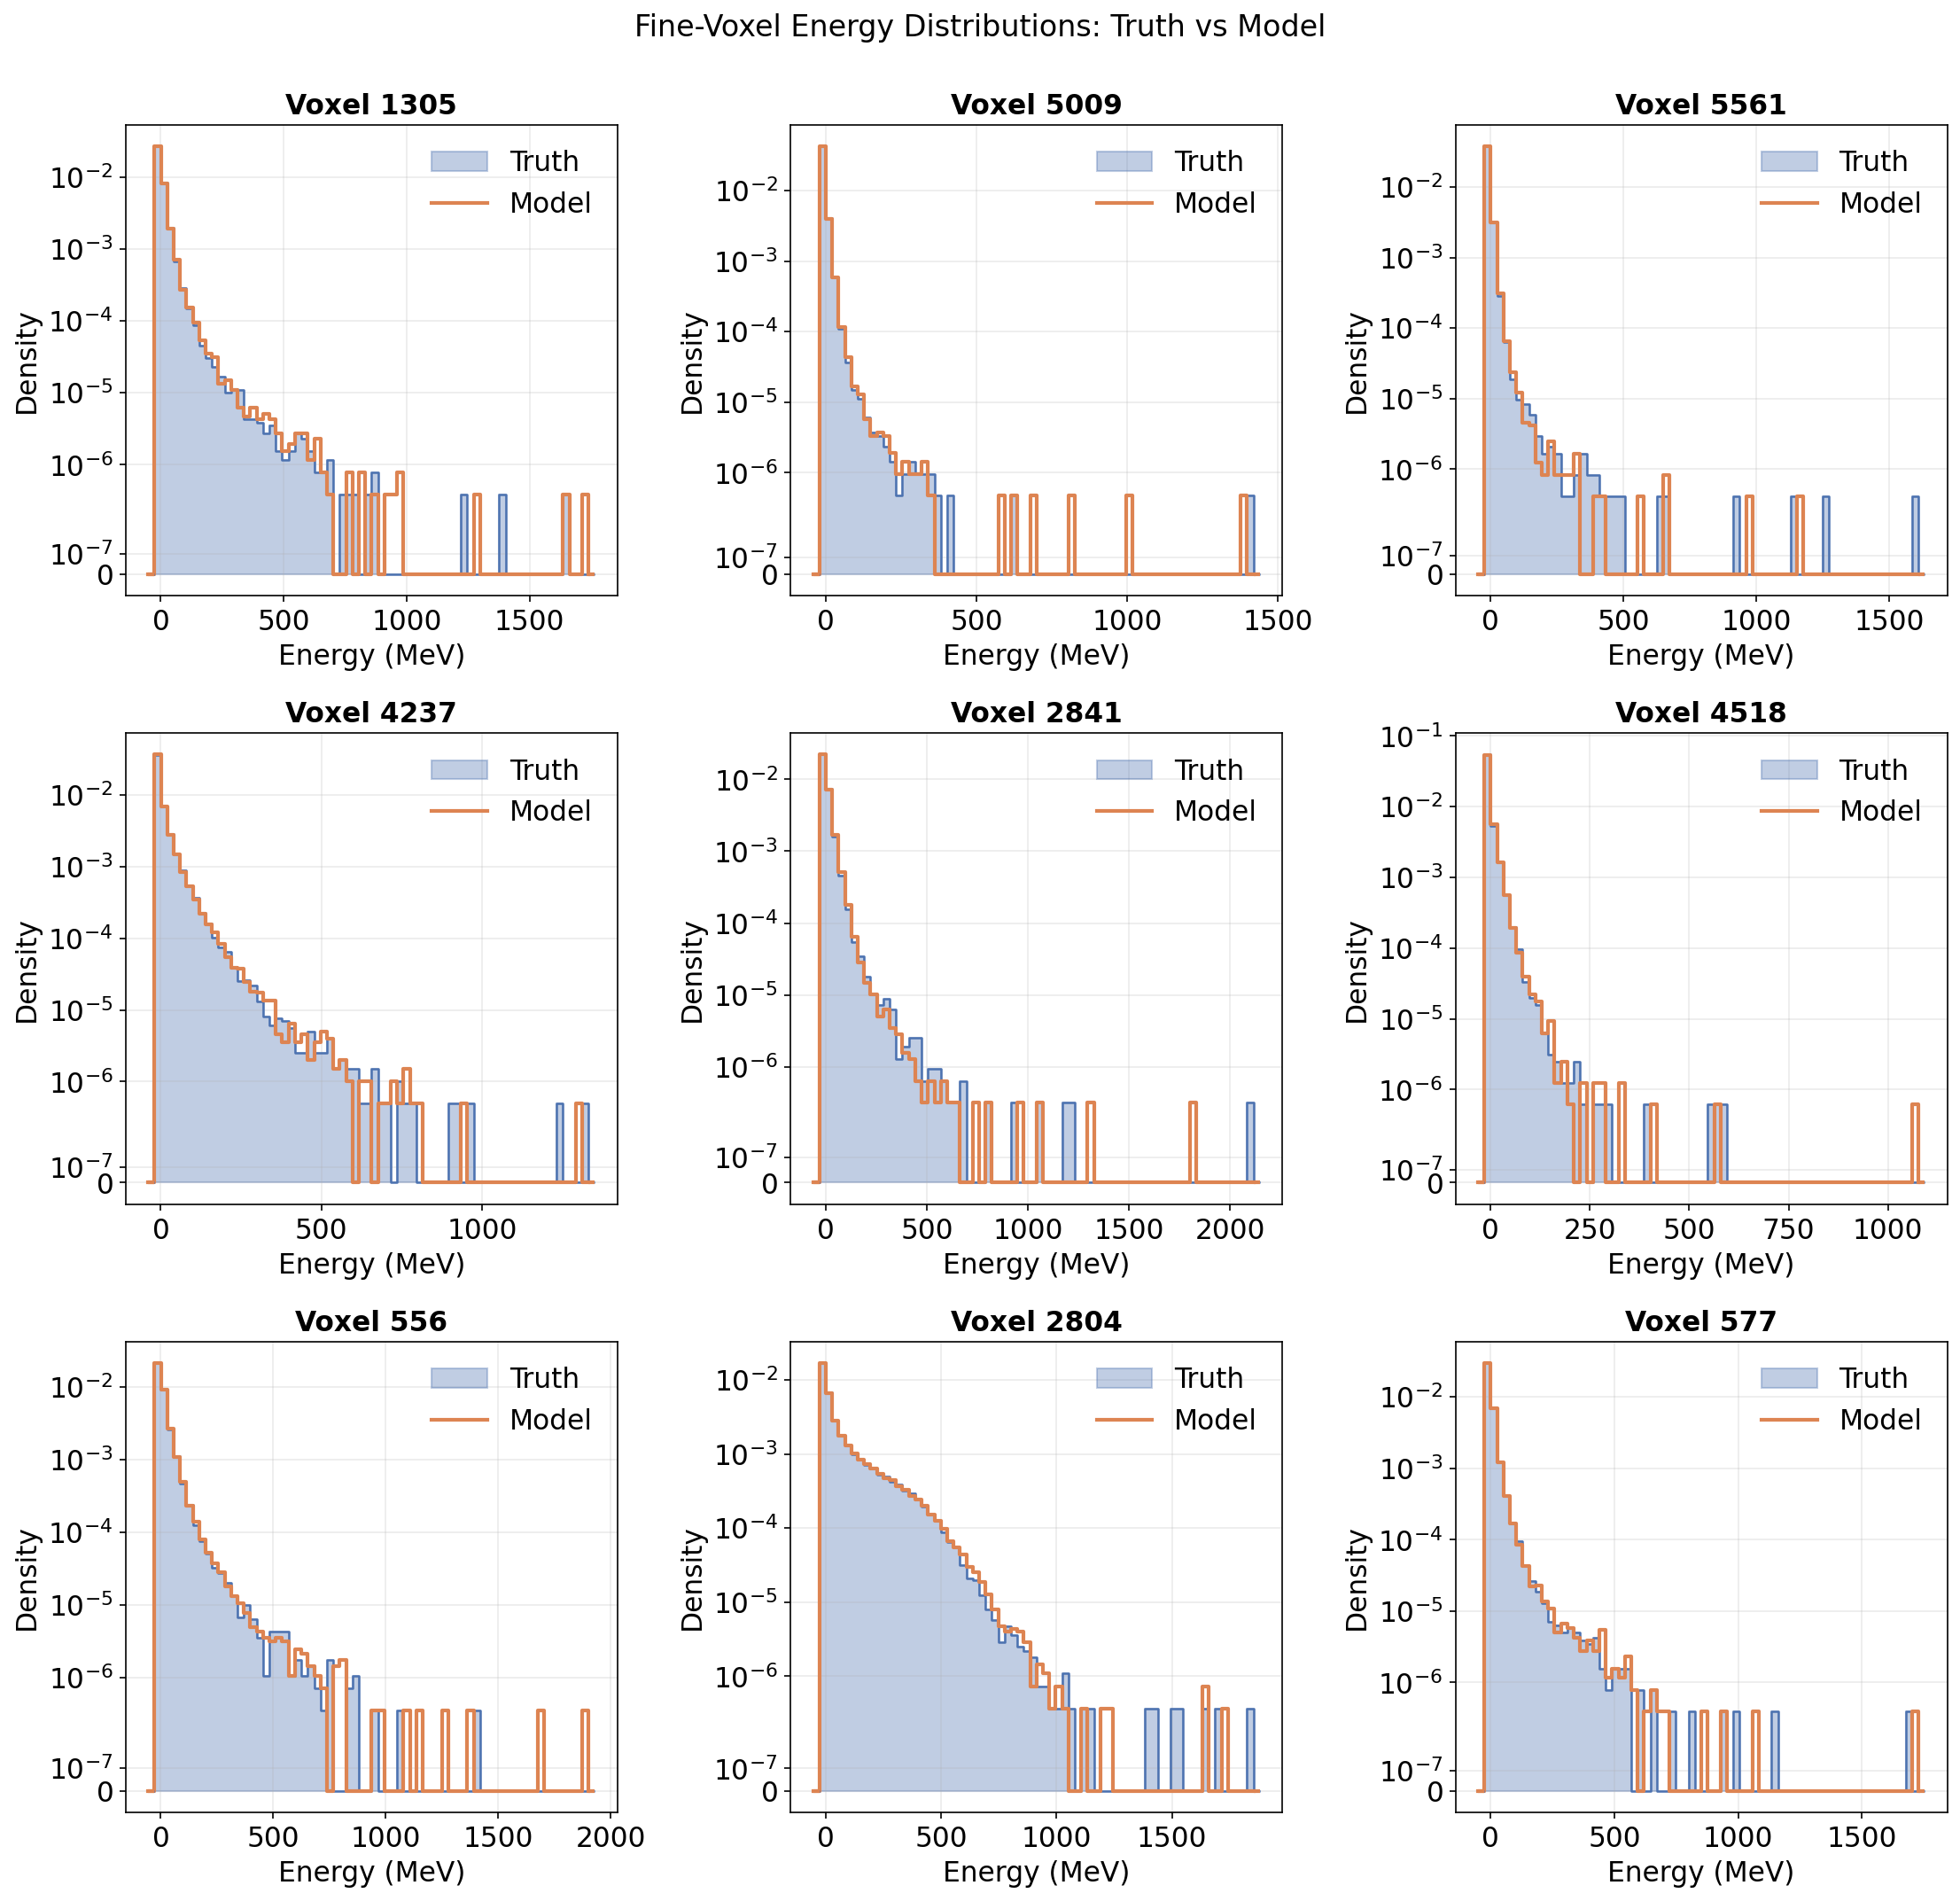

{'dims': [1305, 5009, 5561, 4237, 2841, 4518, 556, 2804, 577],
 'bins': 70,
 'nrows': 3,
 'ncols': 3}

In [18]:
# Plot 9 random voxels in a 3x3 grid, symlog y-axis
plot_voxel_histograms_1d(
    input_true, input_gen,
    dims=None, k=9, random=True, seed=42,
    ncols=3, bins=70,
    y_scale='symlog'
)


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple

def _finite_flatten(x: np.ndarray) -> np.ndarray:
    """Flatten to 1D and keep finite values (zeros kept)."""
    x = np.asarray(x).reshape(-1)
    return x[np.isfinite(x)]

def plot_flattened_overlaid_1d(
    input_true: np.ndarray,
    input_gen:  np.ndarray,
    *,
    bins: int = 100,
    figsize: Tuple[float, float] = (8.5, 5.0),
    truth_color: str = '#4C72B0',   # same palette as your triptych
    model_color: str = '#DD8452',
    range_pad: float = 0.03,
    tight: bool = True,
    save_path: Optional[str] = None,
    # Axis scaling (match triptych options)
    x_scale: Union[str, dict] = 'linear',   # 'linear' or 'symlog'
    y_scale: Union[str, dict] = 'linear',
    x_linthresh: Optional[float] = None,
    y_linthresh: Optional[float] = None,
    x_label: str = 'Energy (MeV)',
    y_label: str = 'Density',
    title: str = 'Global Energy Distribution (All Voxels Flattened)'
):
    """
    Superimpose 1D density histograms of Truth (filled) and Model (step)
    after flattening (N, D) -> (N·D,) for both arrays.
    Styling and behavior match your plot_centroid_triptych.
    """
    # --- validations ---
    if input_true.shape != input_gen.shape:
        raise ValueError(f"Shape mismatch: true {input_true.shape} vs gen {input_gen.shape}")
    if input_true.ndim != 2:
        raise ValueError("Inputs must be 2D arrays (N, D).")

    # --- flatten & filter ---
    t = _finite_flatten(input_true)
    g = _finite_flatten(input_gen)
    if t.size == 0 or g.size == 0:
        raise ValueError("No finite values to plot after flattening.")

    # --- common range with small padding (like triptych) ---
    xmin = float(min(t.min(), g.min()))
    xmax = float(max(t.max(), g.max()))
    dx = xmax - xmin
    pad = range_pad * dx if dx > 0 else 1.0
    rng = (xmin - pad, xmax + pad)

    # --- density histograms with shared edges ---
    t_counts, edges = np.histogram(t, bins=bins, range=rng, density=True)
    g_counts, _     = np.histogram(g, bins=bins, range=rng, density=True)

    # stairs arrays for the filled Truth
    stairs_x = np.repeat(edges, 2)[1:-1]
    stairs_y_t = np.repeat(t_counts, 2)

    # --- plot ---
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Truth: filled + thin outline
    ax.fill_between(stairs_x, stairs_y_t, step='post',
                    color=truth_color, alpha=0.35, label='Truth')
    ax.step(edges[:-1], t_counts, where='post',
            color=truth_color, linewidth=1.2)

    # Model: thicker step line
    ax.step(edges[:-1], g_counts, where='post',
            color=model_color, linewidth=2.0, label='Model')

    # close first/last bins visually (match triptych)
    if len(t_counts):
        ax.hlines(t_counts[0], edges[0],  edges[1],  color=truth_color, linewidth=1.2)
        ax.hlines(t_counts[-1], edges[-2], edges[-1], color=truth_color, linewidth=1.2)
    if len(g_counts):
        ax.hlines(g_counts[0], edges[0],  edges[1],  color=model_color, linewidth=2.0)
        ax.hlines(g_counts[-1], edges[-2], edges[-1], color=model_color, linewidth=2.0)

    # labels & styling
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=12, loc='best')

    # --- axis scales (same logic as triptych) ---
    # X scale
    if x_scale == 'symlog':
        default_x_lt = max(1e-12, (xmax - xmin) * 0.01)
        ax.set_xscale('symlog', linthresh=default_x_lt if x_linthresh is None else x_linthresh)
    elif x_scale != 'linear':
        raise ValueError(f"x_scale must be 'linear' or 'symlog' (got {x_scale})")

    # Y scale
    if y_scale == 'symlog':
        pos_vals = np.concatenate([t_counts[t_counts > 0], g_counts[g_counts > 0]])
        default_y_lt = float(pos_vals.min()) if pos_vals.size else 1e-12
        ax.set_yscale('symlog', linthresh=default_y_lt if y_linthresh is None else y_linthresh)
    elif y_scale != 'linear':
        raise ValueError(f"y_scale must be 'linear' or 'symlog' (got {y_scale})")

    if tight:
        fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    plt.xlim(left = -500)
    plt.yticks([0, 1e-10, 1e-8, 1e-6, 0.0001, 0.0010])
    plt.show()

    return {
        'bins': int(bins),
        'range': rng,
        'n_true_flat': int(t.size),
        'n_gen_flat': int(g.size),
    }

In [20]:
print(np.min(input_true))

0.0


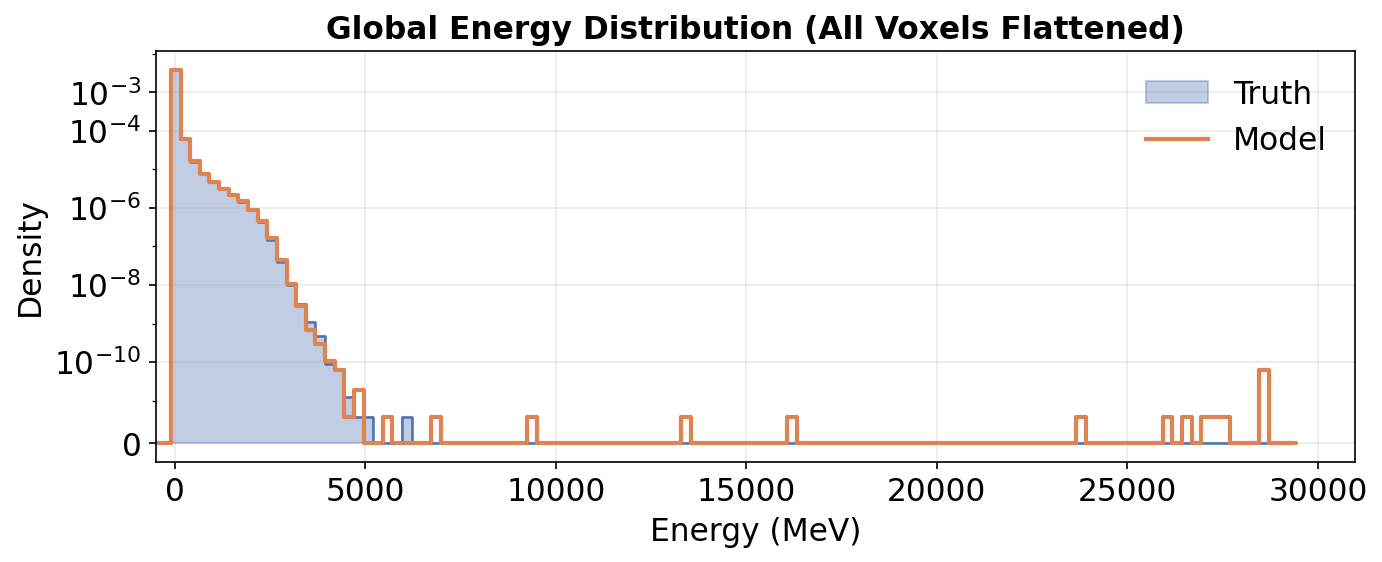

{'bins': 120,
 'range': (-858.1173046875, 29462.0274609375),
 'n_true_flat': 648000000,
 'n_gen_flat': 648000000}

In [21]:
plot_flattened_overlaid_1d(
    input_true, input_gen,
    bins=120,
    figsize=(9.5,4.0),
    x_scale='linear', y_scale='symlog', y_linthresh = 1e-11, x_linthresh=1e4  # or both 'linear'
)

In [22]:
def plot_flattened_hist_diff(
    input_true: np.ndarray,
    input_gen:  np.ndarray,
    *,
    bins: int = 100,
    figsize: Tuple[float, float] = (8.5, 4.0),
    truth_color: str = '#4C72B0',
    model_color: str = '#DD8452',
    diff_color: str = '#333333',
    range_pad: float = 0.03,
    tight: bool = True,
    save_path: Optional[str] = None,
    # Axis scaling
    x_scale: Union[str, dict] = 'linear',   # 'linear' or 'symlog'
    y_scale: Union[str, dict] = 'linear',   # 'linear' or 'symlog'
    x_linthresh: Optional[float] = None,
    y_linthresh: Optional[float] = None,
    x_label: str = 'Energy (MeV)',
    y_label: str = 'Model − Truth (density)',
    title: str = 'Bin-wise Difference: Model − Truth (Flattened Histogram)'
):
    """
    Plot the bin-wise difference between model and truth 1D density histograms,
    after flattening (N, D) -> (N·D,) for both arrays.

    Uses the same binning strategy as plot_flattened_overlaid_1d:
    - common range with small padding
    - density=True histograms
    - difference = g_counts - t_counts
    """
    # --- validations ---
    if input_true.shape != input_gen.shape:
        raise ValueError(f"Shape mismatch: true {input_true.shape} vs gen {input_gen.shape}")
    if input_true.ndim != 2:
        raise ValueError("Inputs must be 2D arrays (N, D).")

    # --- flatten & filter ---
    t = _finite_flatten(input_true)
    g = _finite_flatten(input_gen)
    if t.size == 0 or g.size == 0:
        raise ValueError("No finite values to plot after flattening.")
    
    # --- check for negative values ---
    neg_t = t[t < 0]
    neg_g = g[g < 0]
    
    if neg_t.size > 0:
        print(f"[Warning] Truth has {neg_t.size} negative values. Examples:", neg_t[:10])
    if neg_g.size > 0:
        print(f"[Warning] Model has {neg_g.size} negative values. Examples:", neg_g[:10])


    # --- common range with small padding (same logic as overlay plot) ---
    xmin = float(min(t.min(), g.min()))
    xmax = float(max(t.max(), g.max()))
    dx = xmax - xmin
    pad = range_pad * dx if dx > 0 else 1.0
    rng = (xmin - pad, xmax + pad)

    # --- density histograms with shared edges ---
    t_counts, edges = np.histogram(t, bins=bins, range=rng, density=True)
    g_counts, _     = np.histogram(g, bins=bins, range=rng, density=True)

    diff_counts = g_counts - t_counts
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    # --- plot ---
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # zero line for reference
    ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)

    # bar-style or step-style residuals; here we use a filled bar-like look
    ax.step(edges[:-1], diff_counts, where='post',
        color=diff_color, linewidth=1.8, label='Model − Truth')


    # labels & styling
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.25)
    #ax.legend(frameon=False, fontsize=12, loc='best')

    # --- axis scales ---
    # X scale
    if x_scale == 'symlog':
        default_x_lt = max(1e-12, (xmax - xmin) * 0.01)
        ax.set_xscale('symlog', linthresh=default_x_lt if x_linthresh is None else x_linthresh)
    elif x_scale != 'linear':
        raise ValueError(f"x_scale must be 'linear' or 'symlog' (got {x_scale})")

    # Y scale (note: diff can be negative; symlog handles +/-)
    if y_scale == 'symlog':
        nonzero = diff_counts[diff_counts != 0]
        default_y_lt = float(np.min(np.abs(nonzero))) if nonzero.size else 1e-12
        ax.set_yscale('symlog', linthresh=default_y_lt if y_linthresh is None else y_linthresh)
    elif y_scale != 'linear':
        raise ValueError(f"y_scale must be 'linear' or 'symlog' (got {y_scale})")

    if tight:
        fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    plt.xlim(left = -100)
    plt.yticks([-1e-5, -1e-8, -5e-10, 0, 5e-10, 1e-8, 1e-5])
    plt.show()

    return {
        'bins': int(bins),
        'range': rng,
        'bin_edges': edges,
        'bin_centers': bin_centers,
        'true_counts': t_counts,
        'gen_counts': g_counts,
        'diff_counts': diff_counts,
        'n_true_flat': int(t.size),
        'n_gen_flat': int(g.size),
    }


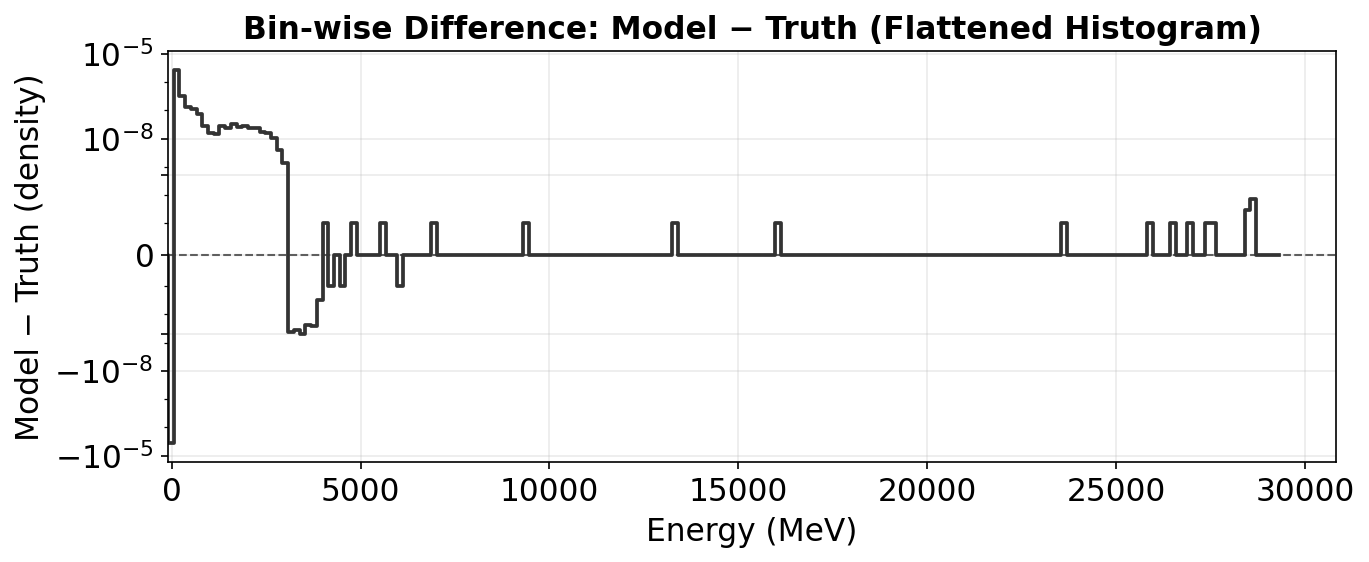

In [23]:
info_diff = plot_flattened_hist_diff(
    input_true, input_gen,
    bins=200,
    figsize=(9.5,4.0),
    x_scale='linear', y_scale='symlog', y_linthresh=1e-11, x_linthresh=8e3
)

# Full Event Visualization with HLF
Visualize full calorimeter events using HighLevelFeatures (HLF) from CaloChallenge:
- Original shower (truth from Geant4)
- Coarse representation
- Super-resolution generated shower

In [24]:
# Load HLF plotter from CaloChallenge code
import sys
sys.path.append('/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code')
from HighLevelFeatures import HighLevelFeatures as HLF
import h5py
import Sample
import Plot_helper
import tensorflow as tf

# Initialize HLF object for dataset 2 (Mode A: electrons)
HLF_2 = HLF('electron', filename='/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code/binning_dataset_2.xml')

print("HLF plotter loaded successfully!")

2025-11-25 15:52:04.324090: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 15:52:04.348046: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 15:52:04.847328: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-11-25 15:52:04.847328: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


[0, 144, 288, 432, 576, 720, 864, 1008, 1152, 1296, 1440, 1584, 1728, 1872, 2016, 2160, 2304, 2448, 2592, 2736, 2880, 3024, 3168, 3312, 3456, 3600, 3744, 3888, 4032, 4176, 4320, 4464, 4608, 4752, 4896, 5040, 5184, 5328, 5472, 5616, 5760, 5904, 6048, 6192, 6336, 6480]
HLF plotter loaded successfully!


In [25]:
# Setup paths and event selection
import numpy as np
cache_file = "/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5"
results_h5 = "/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5"
event_id = 10  # Selected event
MODE = 'A'

# Factors for Mode A
nz, na, nr = 45, 16, 9
zf, af, rf = 5, 2, 1
V, K = nz*na*nr, zf*af*rf
fine_per_event = nz * na * nr * zf * af * rf  # 64800

# Get conditional event (for incident energy)
cond_event, incident_energy, coarse_E_flat = Sample.get_conditional_event(cache_file, MODE, event_id, dtype=tf.float64)
print(f"Event {event_id}: incident energy (preproc) = {incident_energy.numpy()}")

# Load TRUE fine voxelization from results file (ground truth)
with h5py.File(results_h5, "r") as f:
    truth_ds = f["/truth_E"]  # shape [N_events*V, K]
    i0 = event_id * V
    truth_block = truth_ds[i0:i0+V, :]  # [V, K] = [648, 10]
    
original_shower = truth_block.reshape(1, -1).astype(np.float64)  # [1, 64800]
print(f"Original shower (fine) shape: {original_shower.shape}")

# Get incident energy for title
with h5py.File(cache_file, "r") as f:
    e_inc = f["incident_energies"][event_id].item()
print(f"Incident energy: {e_inc:.1f} MeV")

# Load generated fine shower from results file
def load_generated_fine_from_results(results_h5: str, event_idx: int) -> np.ndarray:
    with h5py.File(results_h5, "r") as f:
        ds = f["/model_E"]  # shape [N_events*V, K]
        i0 = event_idx * V
        block = ds[i0:i0+V, :]  # [V, K] = [648, 10]
    gen_fine = block.reshape(1, -1).astype(np.float64)  # [1, 64800]
    return gen_fine

# Get generated shower (fine grid)
full_calo: np.ndarray
try:
    _ = MAF  # type: ignore # check existence
    fine_samples = Sample.sample_event(flow=MAF, base_dist=base_dist, cond_event=cond_event,
                                       clip_latent=False, latent_clip_value=4.0, verbose=False)
    fine_samples_inverted = Sample.invert_transform_fine(fine_samples, coarse_E_flat, alpha=1e-6, dtype=tf.float64)
    full_calo = Sample.reshape_to_calo_flat(fine_samples_inverted, mode=MODE).numpy()
    print("Generated via model sampling.")
except Exception as e:
    print(f"No trained model in memory — loading generated from results file.")
    full_calo = load_generated_fine_from_results(results_h5, event_id)

print(f"Generated shower shape: {full_calo.shape}")

# Load coarse representation and UPSAMPLE to fine grid by distributing energy evenly
with h5py.File(cache_file, "r") as f:
    showers_raw = f["/showers_raw"][event_id].astype(np.float64)  # [45,16,9]

# Expand coarse to fine grid: each coarse voxel energy is split evenly across its K=10 fine voxels
coarse_expanded = np.repeat(showers_raw[..., None], zf, axis=-1)  # add z-fine dim
coarse_expanded = np.repeat(coarse_expanded[..., None], af, axis=-1)  # add a-fine dim  
coarse_expanded = np.repeat(coarse_expanded[..., None], rf, axis=-1)  # add r-fine dim
# Now shape is [45, 16, 9, 5, 2, 1], distribute evenly
coarse_expanded = coarse_expanded / K  # each fine voxel gets 1/10 of coarse energy
coarse_flat = coarse_expanded.reshape(1, -1)  # [1, 64800]
print(f"Coarse (upsampled to fine) shape: {coarse_flat.shape}")

print("\n✓ All arrays now on fine grid (64800 voxels) for HLF visualization")

2025-11-25 15:52:24.402209: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43611 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:87:00.0, compute capability: 8.9
2025-11-25 15:52:24.402729: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43611 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:c3:00.0, compute capability: 8.9
2025-11-25 15:52:24.403176: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43611 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:c4:00.0, compute capability: 8.9
2025-11-25 15:52:24.403513: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43611 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:c5:00.0, compute capability: 

Event 10: incident energy (preproc) = 1.3859518766403198
Original shower (fine) shape: (1, 64800)
Incident energy: 769045.0 MeV
No trained model in memory — loading generated from results file.
Generated shower shape: (1, 64800)
Coarse (upsampled to fine) shape: (1, 64800)

✓ All arrays now on fine grid (64800 voxels) for HLF visualization
Coarse (upsampled to fine) shape: (1, 64800)

✓ All arrays now on fine grid (64800 voxels) for HLF visualization


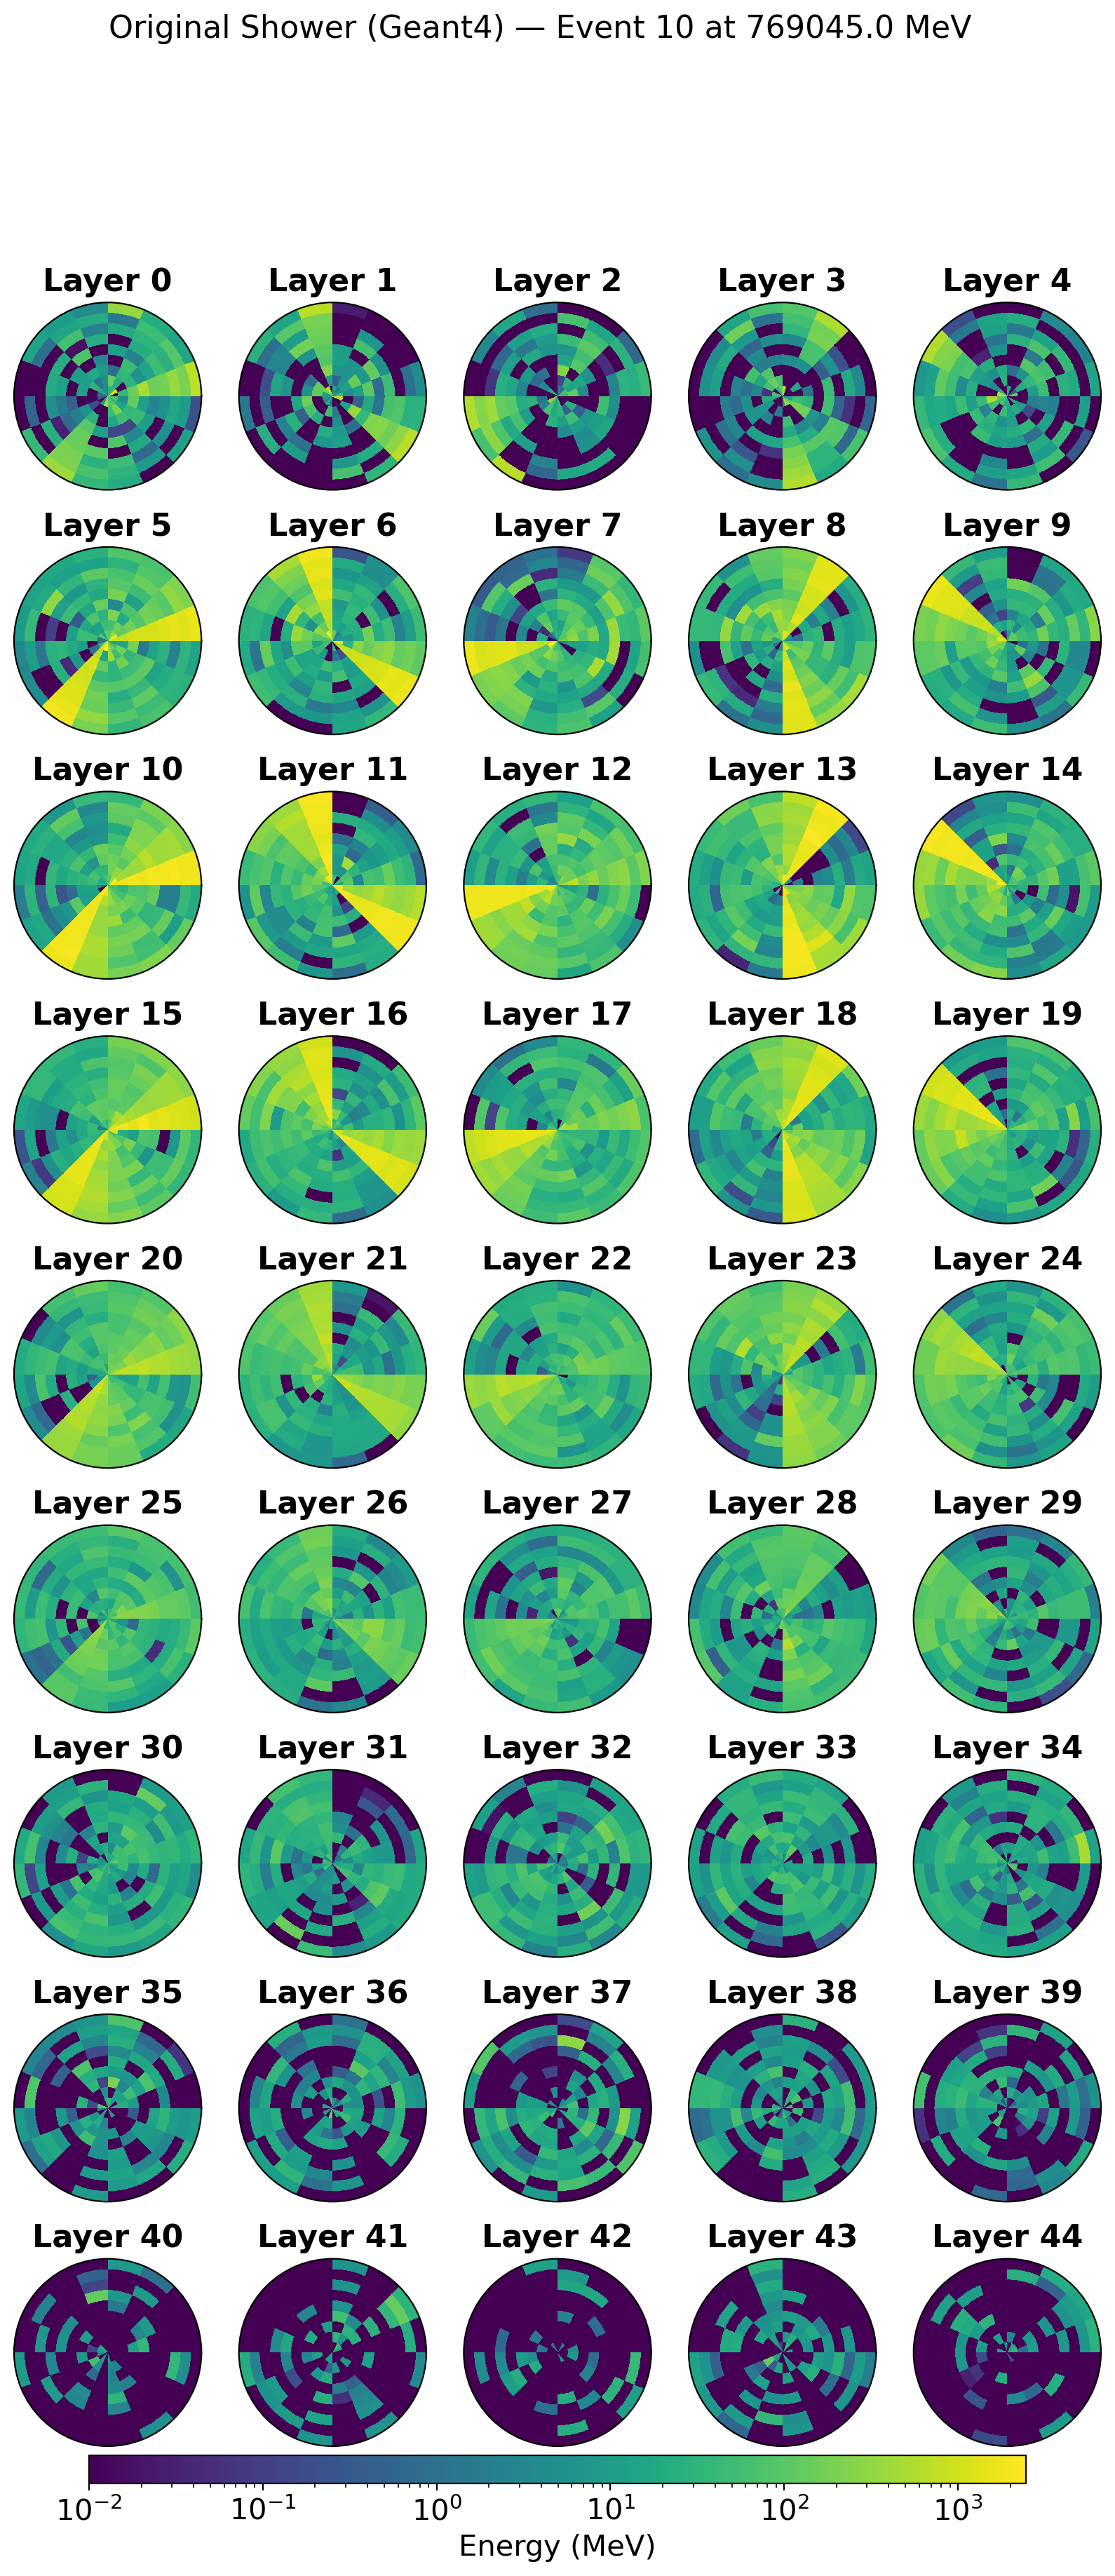

In [26]:
# Plot 1: Original shower (truth from Geant4)
import numpy as np
orig_np = np.asarray(original_shower)
HLF_2.CalculateFeatures(orig_np)
_ = HLF_2.DrawSingleShower(orig_np[0], filename=None,
                            title=f"Original Shower (Geant4) — Event {event_id} at {float(e_inc):.1f} MeV")

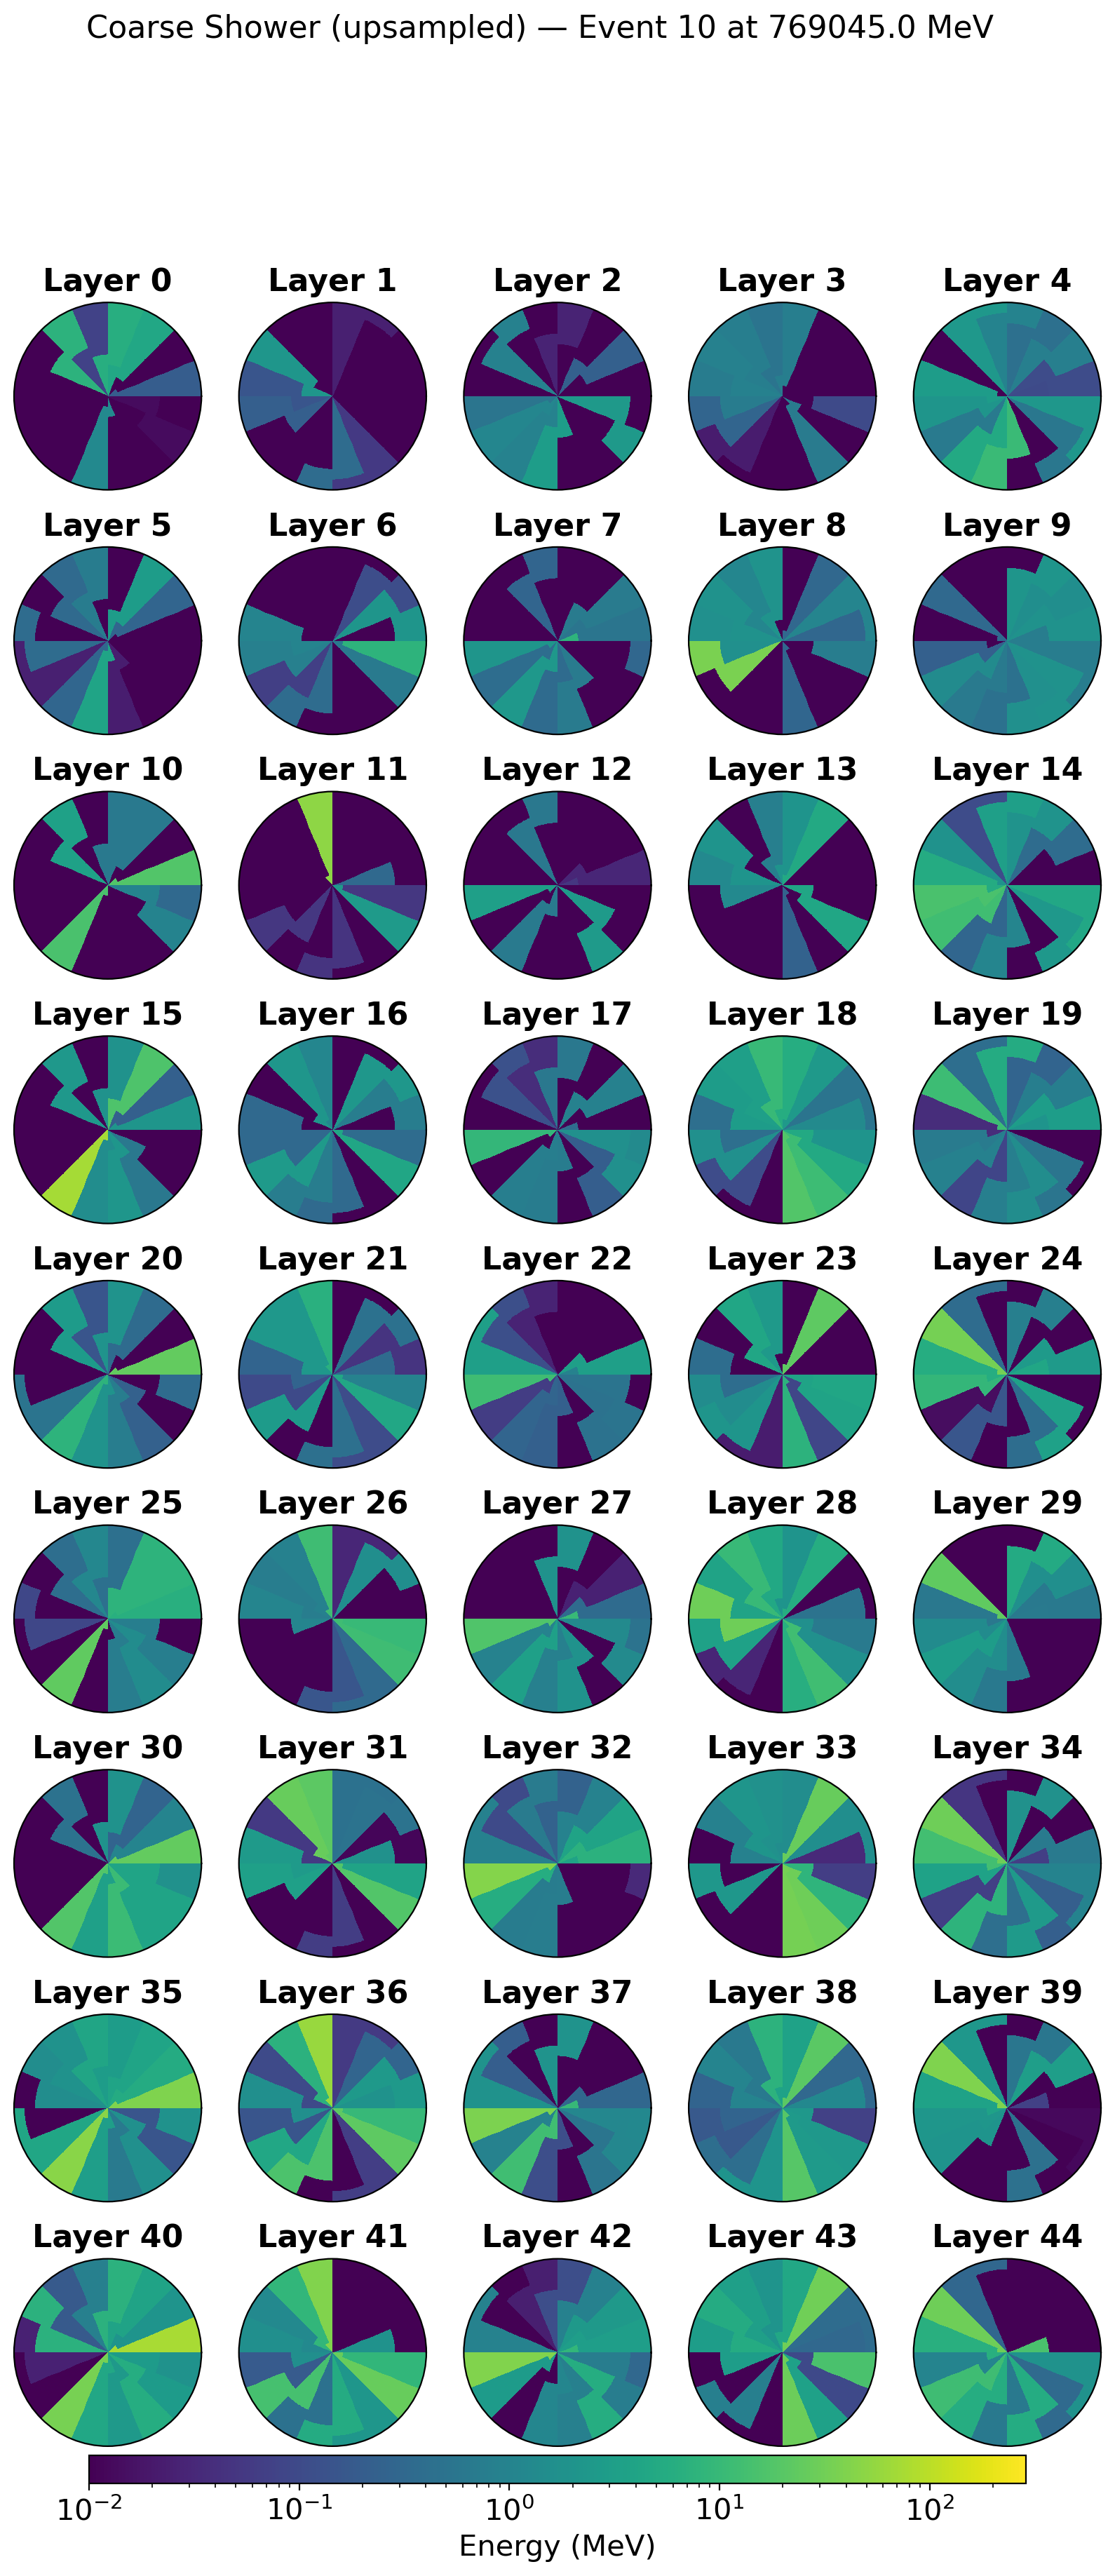

In [27]:
# Plot 2: Coarse representation (upsampled to fine grid)
coarse_np = np.asarray(coarse_flat)
HLF_2.CalculateFeatures(coarse_np)
_ = HLF_2.DrawSingleShower(coarse_np[0], filename=None,
                            title=f"Coarse Shower (upsampled) — Event {event_id} at {float(e_inc):.1f} MeV")

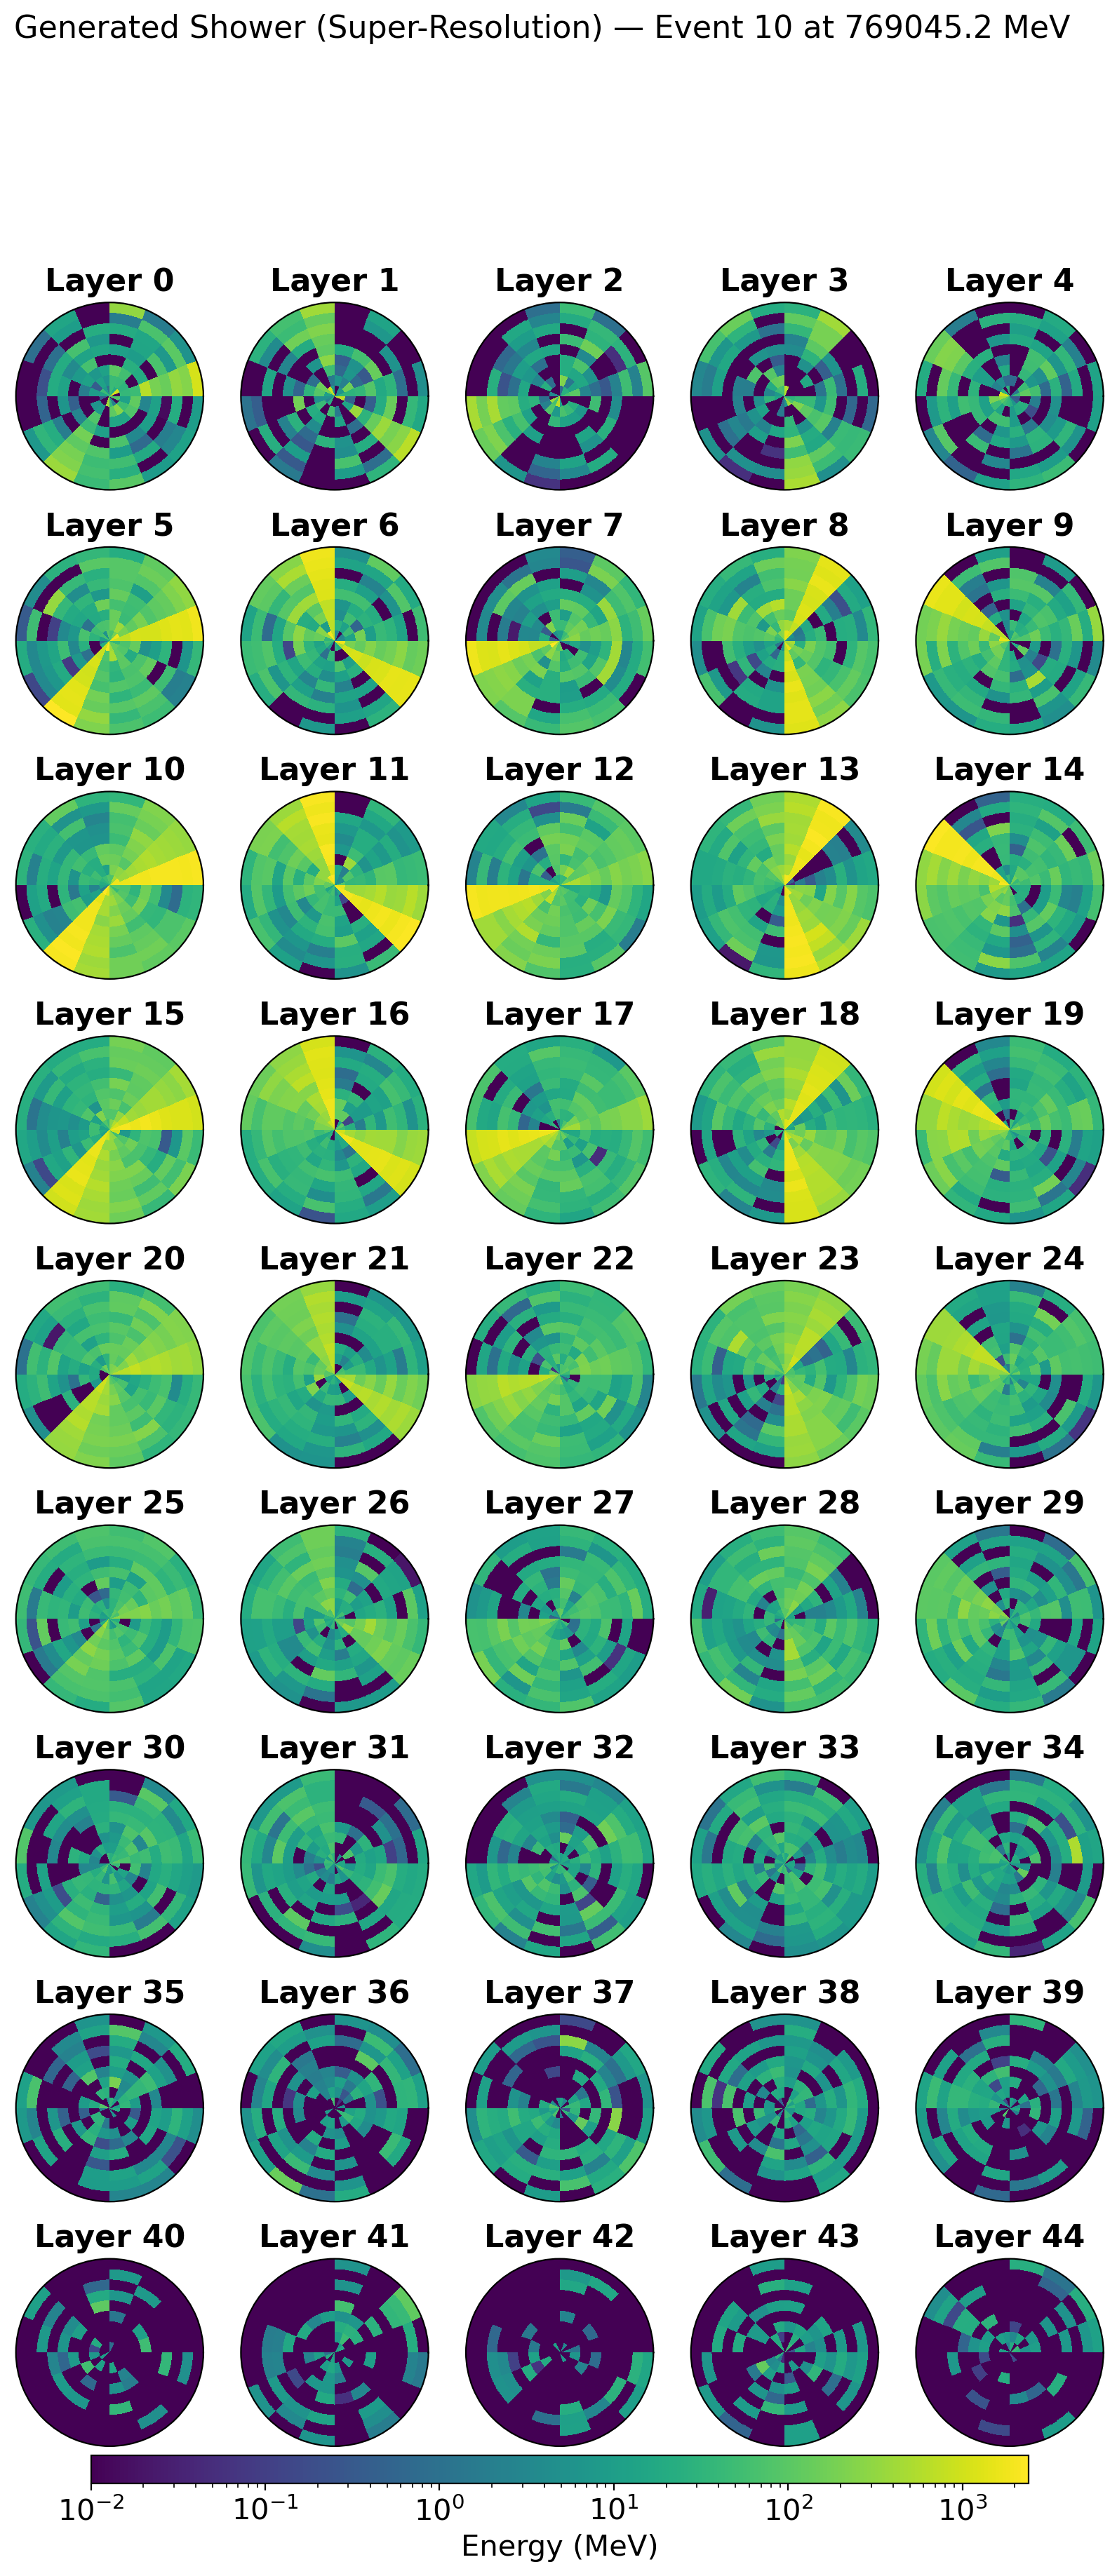

In [28]:
# Plot 3: Generated shower (super-resolution)
full_np = np.asarray(full_calo)
HLF_2.CalculateFeatures(full_np)
incident_energy_mev = (10**incident_energy.numpy()) * (10**4.5)  # revert preprocessing
_ = HLF_2.DrawSingleShower(full_np[0], filename=None,
                            title=f"Generated Shower (Super-Resolution) — Event {event_id} at {incident_energy_mev:.1f} MeV")

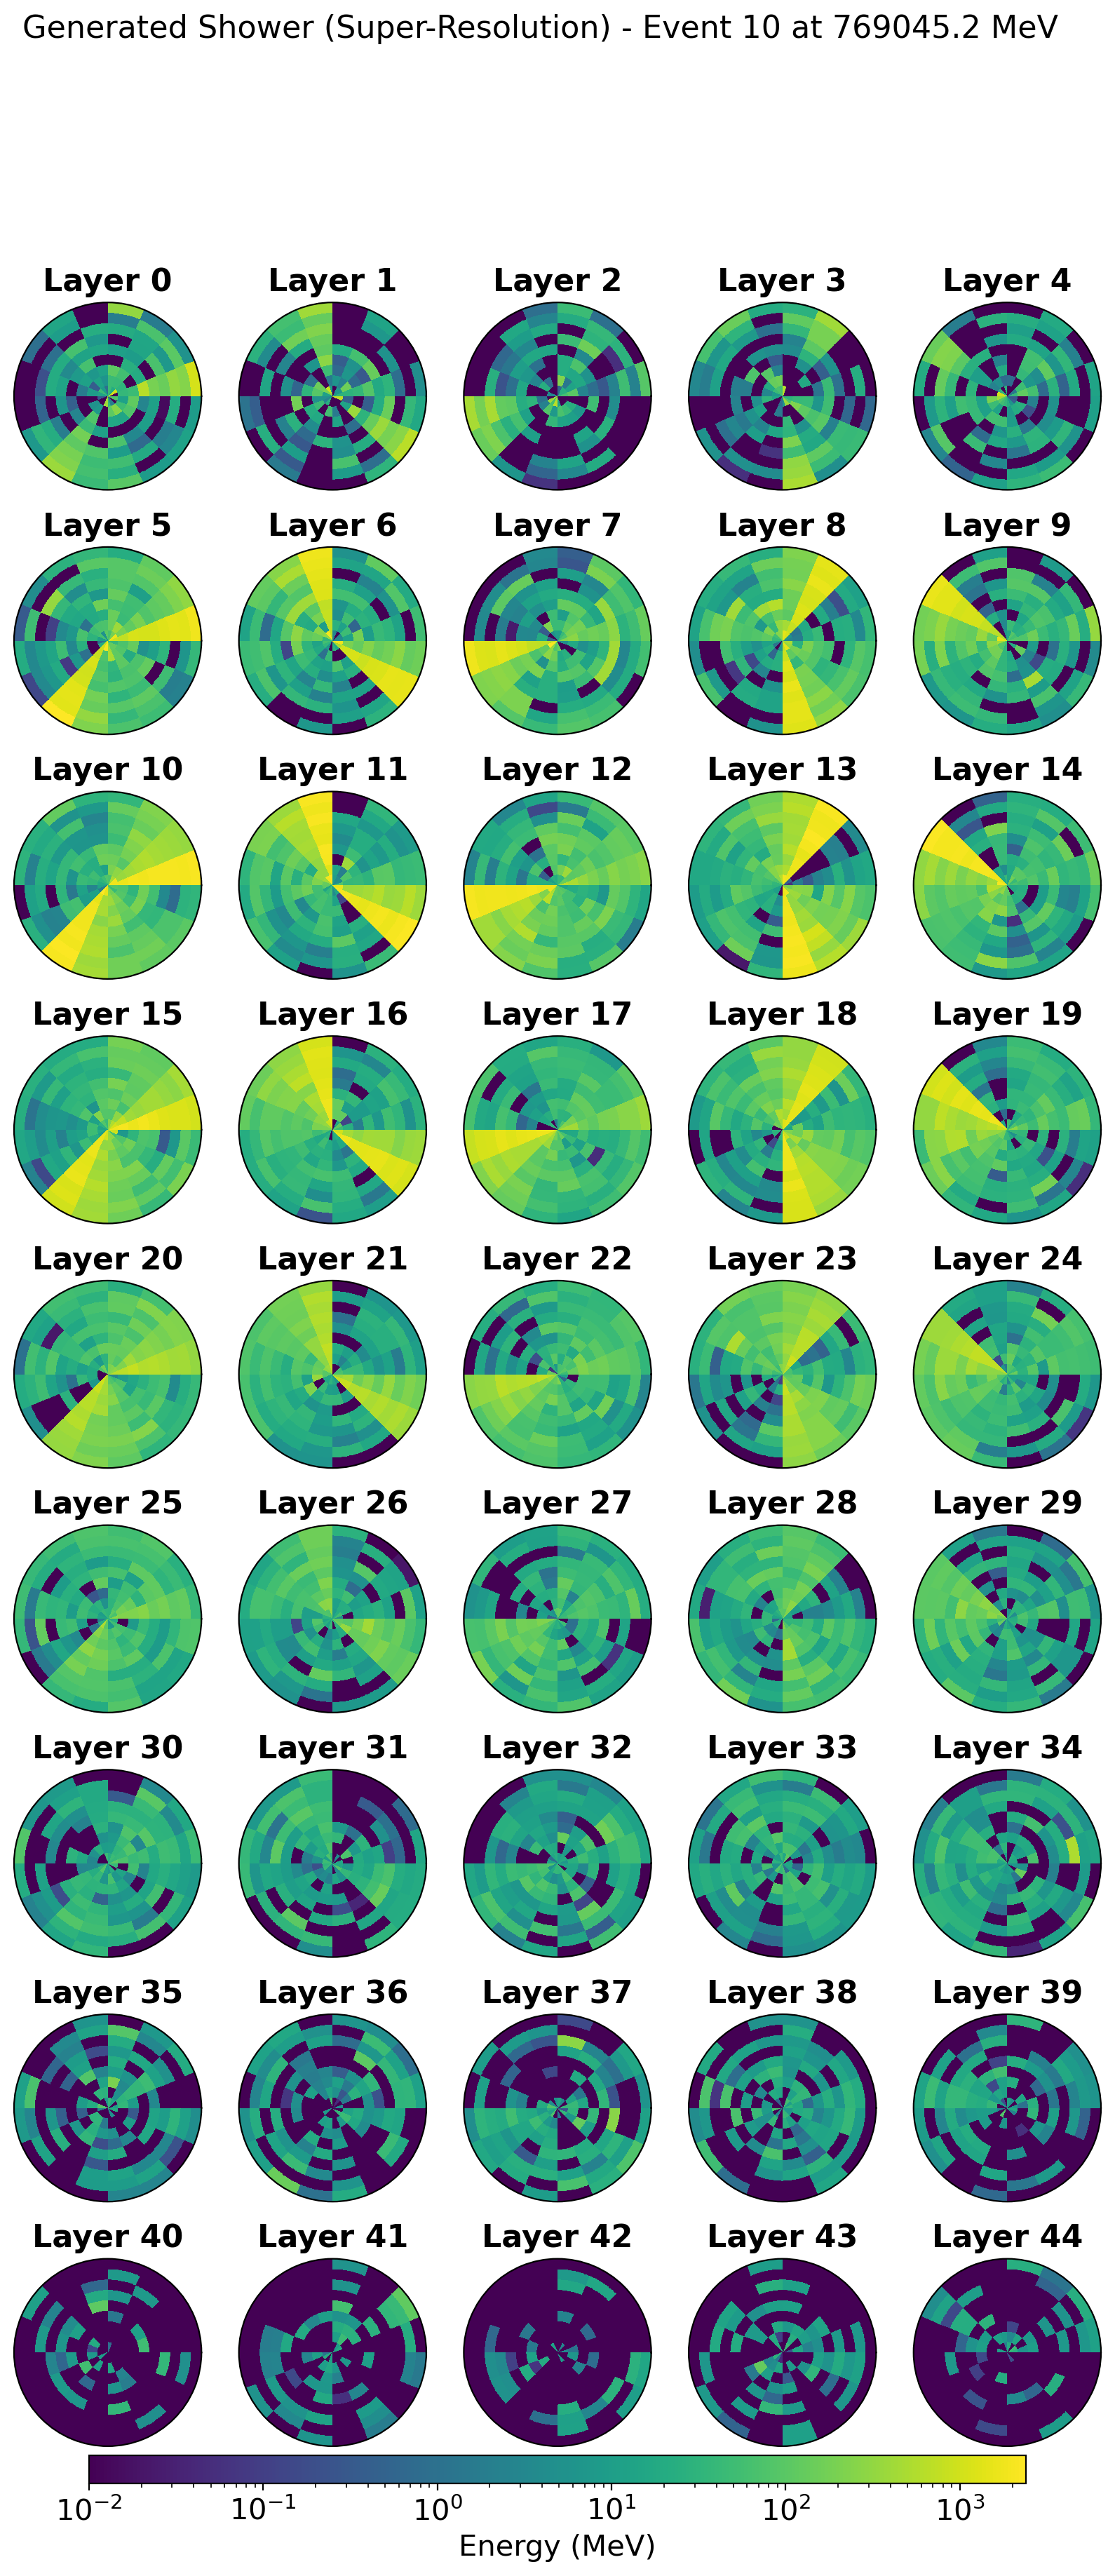

In [29]:
# Plot 3: Generated shower from super-resolution model
HLF_2.CalculateFeatures(full_calo)
incident_energy_mev = (10**incident_energy.numpy())*(10**4.5)  # Revert preprocessing
_ = HLF_2.DrawSingleShower(full_calo[0], filename=None, 
                            title=f"Generated Shower (Super-Resolution) - Event {event_id} at {incident_energy_mev:.1f} MeV")